## 1. Imports

In [1]:
import os
import json
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader

## 2. Config

In [2]:
rlvs_path = '/kaggle/input/datasets/mohamedmustafa/real-life-violence-situations-dataset/Real Life Violence Dataset'
hockey_path = '/kaggle/input/datasets/seldaertrk/hockey-fight/data'
scvd_path = '/kaggle/input/datasets/toluwaniaremu/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted/Test'

print(f"RLVS: {os.listdir(rlvs_path)}")
print(f"hockey Fights: {os.listdir(hockey_path)}")
print(f"SCVD: {os.listdir(scvd_path)}")

RLVS: ['NonViolence', 'Violence']
hockey Fights: ['nofights', 'fights']
SCVD: ['Weaponized', 'Normal', 'Violence']


In [3]:
DATASET_CONFIG = {
    "rlvs": {
        "root": rlvs_path,
        "classes": {
            "Violence": 1,
            "NonViolence": 0
        }
    },
    "hockey": {
        "root": hockey_path,
        "classes": {
            "fights": 1,
            "nofights": 0
        }
    },
    "scvd": {
        "root": scvd_path,
        "classes": {
            "Violence": 1, 
            "Normal": 0, 
            "Weaponized": 1
        }
    }
}

## 3. Dataset preparation

In [4]:
def get_video_files(root_dir, extensions=(".avi", ".mp4")):
    video_files = []
    for root, _, files in os.walk(root_dir):
        for f in files:
            if f.lower().endswith(extensions):
                video_files.append(os.path.join(root, f))
    return video_files


def build_dataframe(dataset_names):
    data = []
    for name in dataset_names:
        cfg = DATASET_CONFIG[name]
        for class_name, label in cfg["classes"].items():
            folder = os.path.join(cfg["root"], class_name)
            videos = get_video_files(folder)
            for path in videos:
                data.append({"path": path, "label": label, "source": name})
    return pd.DataFrame(data)

В EDA були визначені 3 конкретні відеоаномалії, довжина яких більша за 15 секунд. Ці відео видаляються з вибірок.

In [5]:
OUTLIER_VIDEOS = [
    "NV_992.mp4",
    "V_789.mp4",
    "V_398.mp4"
]

In [6]:
def remove_outliers(df):
    mask = ~(
        (df["source"] == "rlvs") &
        (df["path"].apply(lambda x: os.path.basename(x) in OUTLIER_VIDEOS))
    )
    return df[mask].reset_index(drop=True)

In [7]:
def split_dataframe(df, test_size=0.2, val_size=0.5, seed=42):
    train_df, temp_df = train_test_split(
        df, 
        test_size=test_size, 
        stratify=df["label"], 
        random_state=seed
    )
    val_df, test_df = train_test_split(
        temp_df, 
        test_size=1 - val_size, 
        stratify=temp_df["label"], 
        random_state=seed
    )
    return train_df.reset_index(drop=True), \
           val_df.reset_index(drop=True), \
           test_df.reset_index(drop=True)

## 4. Frame sampling

In [8]:
def sample_frames(total_frames, n_frames):
    if total_frames <= n_frames:
        indices = np.linspace(0, total_frames - 1, total_frames)
        indices = np.pad(indices, (0, n_frames - total_frames), mode="edge")
    else:
        indices = np.linspace(0, total_frames - 1, n_frames)
    return indices.astype(int)

## 5. Dataset class

In [9]:
class ViolenceVideoDataset(Dataset):
    def __init__(self, dataframe, n_frames=16, resize_size=(224, 224), transforms=False):
        self.df = dataframe.reset_index(drop=True)
        self.n_frames = n_frames
        self.resize_size = resize_size
        self.transforms = transforms

        self.mean = np.array([0.485, 0.456, 0.406])
        self.std = np.array([0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.df)

    def _get_frames(self, video_path):
        cap = cv2.VideoCapture(video_path)
        
        frames = []
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))    
        indices = sample_frames(total_frames, self.n_frames)

        current = 0
        selected = []

        try:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                if current in indices:
                    frame = cv2.resize(frame, self.resize_size)
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    selected.append(frame)

                current += 1

                if len(selected) == self.n_frames:
                    break
        finally:
            cap.release()

        if len(selected) < self.n_frames:
            selected += [selected[-1]] * (self.n_frames - len(selected))
        return np.stack(selected)


    def _preprocess(self, frames):
        frames = frames.astype(np.float32) / 255.0
        frames = (frames - self.mean) / self.std
        frames = torch.from_numpy(frames)
        frames = frames.permute(0, 3, 1, 2)
        return frames
    
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frames = self._get_frames(row.path)
        
        if self.transforms and random.random() < 0.5:
            frames = np.flip(frames, axis=2)

        frames = self._preprocess(frames)
        label = torch.tensor(row.label).float()
        return frames, label

In [10]:
def build_loaders(train_df, val_df, test_df, n_frames=16, batch_size=8):
    train_loader = DataLoader(
        ViolenceVideoDataset(train_df, n_frames, transforms=True),
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )
    val_loader = DataLoader(
        ViolenceVideoDataset(val_df, n_frames),
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
    )
    test_loader = DataLoader(
        ViolenceVideoDataset(test_df, n_frames),
        batch_size=batch_size,
        shuffle=False
    )
    return train_loader, val_loader, test_loader

## 6. Model factory

In [11]:
def get_model(model_type):
    if model_type == "mobilenet_v2":
        return MobileNetBaseline()
    elif model_type == "resnet18":
        return ResNetBaseline()
    elif model_type == "efficientnet_b0":
        return EfficientNetBaseline()
    else:
        raise ValueError("Unknown model type")


def get_models():
    return {
        "ResNet18": get_model("resnet18"),
        "MobileNetV2": get_model("mobilenet_v2"),
        "EfficientNetB0": get_model("efficientnet_b0")
    }


class MobileNetBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        self.feature_dim = self.base.classifier[1].in_features
        self.base.classifier = nn.Identity()
        self.classifier = nn.Linear(self.feature_dim, 1)

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        features = self.base(x)
        features = features.view(B, T, -1)
        pooled = features.max(dim=1).values  # max pooling по часу
        logits = self.classifier(pooled)     # [B, 1]
        return logits


class ResNetBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.feature_dim = self.base.fc.in_features
        self.base.fc = nn.Identity()
        self.classifier = nn.Linear(self.feature_dim, 1)

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        features = self.base(x)
        features = features.view(B, T, -1)
        pooled = features.max(dim=1).values
        logits = self.classifier(pooled)
        return logits


class EfficientNetBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.feature_dim = self.base.classifier[1].in_features
        self.base.classifier = nn.Identity()
        self.classifier = nn.Linear(self.feature_dim, 1)

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        features = self.base(x)
        features = features.view(B, T, -1)
        pooled = features.max(dim=1).values
        logits = self.classifier(pooled)
        return logits

## 7. Training loop

Зафіксуємо seed для проведення кількох експериментів

In [12]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [13]:
def train_model(model, train_loader, val_loader, device, epochs=5, lr=1e-4):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_val_loss = float("inf")
    best_state = None

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for frames, labels in train_pbar:
            frames, labels = frames.to(device).float(), labels.to(device).float().view(-1, 1)
            
            optimizer.zero_grad()
            logits = model(frames)
            
            loss = criterion(logits, labels)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            train_correct += (preds == labels).sum().item()
            train_pbar.set_postfix({'loss': loss.item()})
            
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for frames, labels in val_loader:
                frames, labels = frames.to(device).float(), labels.to(device).float().view(-1, 1)
                logits = model(frames)

                loss = criterion(logits, labels)
                val_loss += loss.item()

                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).float()
                
                val_correct += (preds == labels).sum().item()
        
        t_loss = train_loss / len(train_loader)
        t_acc = train_correct / len(train_loader.dataset)
        
        v_loss = val_loss / len(val_loader)
        v_acc = val_correct / len(val_loader.dataset)
        
        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        
        print(f"Summary -> Train Acc: {t_acc:.4f}, Val Acc: {v_acc:.4f}")

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_state = model.state_dict()
        
    model.load_state_dict(best_state)
    return model, history

## 8. Evaluation

In [14]:
def evaluate_model(model, dataloader, device):
    model.eval()
    
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for frames, labels in dataloader:
            frames = frames.to(device).float()
            
            logits = model(frames)
            probs = torch.sigmoid(logits)
            
            all_probs.extend(probs.cpu().numpy().reshape(-1))
            all_labels.extend(labels.cpu().numpy().reshape(-1))
    
    y_true = np.array(all_labels).astype(int)
    y_probs = np.array(all_probs)
    
    return y_true, y_probs

## 9. Metrics

In [15]:
def compute_metrics(y_true, y_probs, threshold=0.5):
    y_pred = (y_probs >= threshold).astype(int)
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }
    
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    metrics["fpr"] = fpr
    metrics["tpr"] = tpr
    metrics["roc_auc"] = auc(fpr, tpr)
    
    return metrics


def plot_confusion_matrix(cm, class_names=("Non-Violence", "Violence"), save_path=None, show=True):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Confusion Matrix")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path)
    if show:
        plt.show()
    plt.close()

def plot_roc_curve(fpr, tpr, roc_auc, save_path=None, show=True):
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    
    plt.legend(loc="lower right")
    
    plt.grid(True)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path)

    if show:
        plt.show()
    
    plt.close()


def plot_training_curves(history, save_path=None, show=True):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label="Train Loss")
    plt.plot(epochs, history['val_loss'], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    
    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label="Train Accuracy")
    plt.plot(epochs, history['val_acc'], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    if show:
        plt.show()
    plt.close()

## 9. Experiment runner

In [16]:
def run_single_experiment(model, model_name, 
                          train_loader, val_loader, 
                          test_loader, device, 
                          save_dir, epochs):
    os.makedirs(save_dir, exist_ok=True)
    model, history = train_model(model, train_loader, 
                                 val_loader, device, epochs)
    torch.save(model.state_dict(), os.path.join(save_dir,"model.pt"))
    plot_training_curves(history, os.path.join(save_dir,"training_curves.png"))

    with open(os.path.join(save_dir,"history.json"),"w") as f:
        json.dump(history,f)

    results = {}
    for split_name, loader in {
        "val": val_loader,
        "test": test_loader
    }.items():
        y_true, y_probs = evaluate_model(model, loader, device)
        metrics = compute_metrics(y_true,y_probs)
        results[split_name] = {
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"]
        }
        print(f"\n=== {split_name.upper()} METRICS ===")
        print(f"Accuracy : {metrics['accuracy']:.4f}")
        print(f"Precision: {metrics['precision']:.4f}")
        print(f"Recall   : {metrics['recall']:.4f}")
        print(f"F1-score : {metrics['f1']:.4f}")
        print(f"ROC AUC  : {metrics['roc_auc']:.4f}")
        plot_confusion_matrix(metrics["confusion_matrix"],
                    save_path=os.path.join(save_dir, f"{split_name}_cm.png")
    )
        plot_roc_curve(metrics["fpr"], metrics["tpr"], 
                       metrics["roc_auc"], 
                       os.path.join(save_dir,f"{split_name}_roc.png"))
    with open(os.path.join(save_dir,"metrics.json"),"w") as f:
        json.dump(results,f,indent=4)
    return results

In [17]:
def run_experiment(train_df, val_df, test_df, 
                   device, epochs=5, seeds=(42,43,44)):
    results_all = {}
    loaders = build_loaders(train_df, val_df, test_df)
    train_loader, val_loader, test_loader = loaders

    for seed in seeds:
        print(f"\nSeed {seed}")
        set_seed(seed)
        models_dict = get_models()

        for model_name, model in models_dict.items():
            print(f"\nModel {model_name}")
            save_dir = f"./experiments/{model_name}/seed_{seed}"
            results = run_single_experiment(
                model, model_name, train_loader, 
                val_loader, test_loader, device, 
                save_dir, epochs)

            results_all[(model_name,seed)] = results
    return results_all

In [18]:
def summarize_results(results):
    summary = {}
    for (model_name,seed),res in results.items():
        if model_name not in summary:
            summary[model_name] = {"test":[]}
        summary[model_name]["test"].append(res["test"]["f1"])

    for model in summary:
        scores = summary[model]["test"]
        print(f"{model} F1 mean: {np.mean(scores)} std: {np.std(scores)}")

## 10. Run Experiments

In [19]:
def prepare_dataset_splits(dataset_names, test_dataset=None, seed=42, val_size=0.2):
    df = build_dataframe(dataset_names)
    df = remove_outliers(df)

    if test_dataset:
        df_test = build_dataframe([test_dataset])
        df_test = remove_outliers(df_test)
    else:
        df_test = None

    train_df, val_df, temp_df = split_dataframe(df, test_size=val_size, val_size=0.5, seed=seed)
    test_df = df_test if df_test is not None else temp_df
    return train_df, val_df, test_df

In [20]:
def run_scenario(model_name, train_datasets, 
                 test_dataset=None, device="cpu", 
                 epochs=5, n_frames=16, batch_size=8, seeds=(42,43,44)):
    results_all = {}
    for seed in seeds:
        print(f"\n=== Seed {seed} ===")
        
        set_seed(seed)
        train_df, val_df, test_df = prepare_dataset_splits(train_datasets, test_dataset, seed)
        train_loader, val_loader, test_loader = build_loaders(train_df, val_df, test_df, n_frames=16, batch_size=8)
        
        model = get_model(model_name)
        
        save_dir = f"./experiments/{model_name}_{'_'.join(train_datasets)}_seed_{seed}"
        
        results = run_single_experiment(model, model_name, train_loader,val_loader,test_loader,device,save_dir,epochs)
        results_all[(model_name,seed)] = results
    return results_all

In [21]:
def cross_validation_splits(df, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    splits = []
    X = df.index.values
    y = df.label.values
    for train_idx,val_idx in skf.split(X, y):
        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)
        splits.append((train_df, val_df))
    return splits



========== MODEL: resnet18 ==========

--- Scenario: RLVS_train ---

=== Seed 44 ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 217MB/s]


Epoch 1/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

[h264 @ 0x2f4ce740] mb_type 104 in P slice too large at 98 31
[h264 @ 0x2f4ce740] error while decoding MB 98 31


Summary -> Train Acc: 0.8848, Val Acc: 0.9750


...

[h264 @ 0x3fa1d680] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3fa1d680] error while decoding MB 98 31


Summary -> Train Acc: 0.9693, Val Acc: 0.9700


Epoch 5/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

[h264 @ 0x3fb7ecc0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3fb7ecc0] error while decoding MB 98 31


Summary -> Train Acc: 0.9530, Val Acc: 0.9200


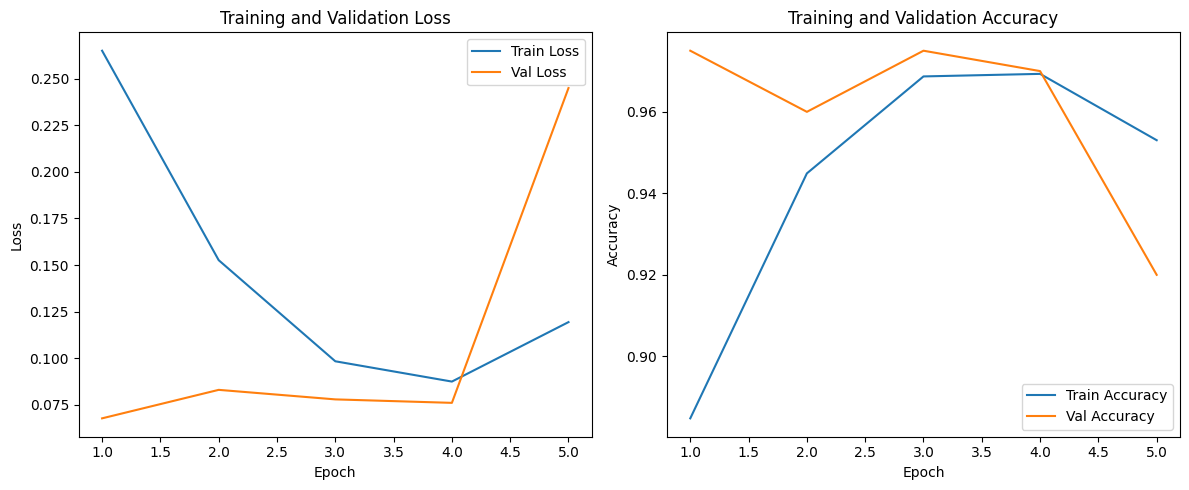


=== VAL METRICS ===
Accuracy : 0.9200
Precision: 1.0000
Recall   : 0.8400
F1-score : 0.9130
ROC AUC  : 0.9941


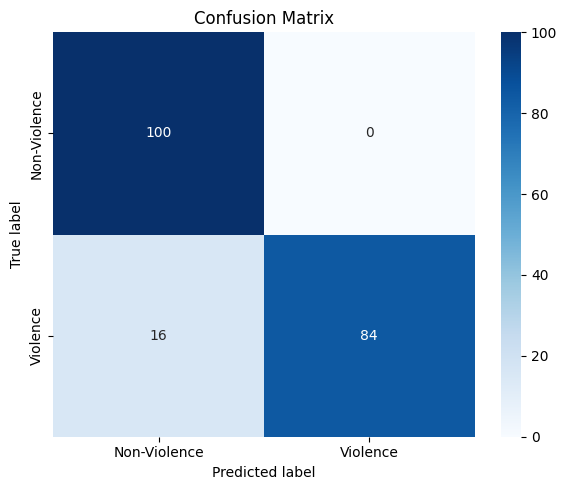

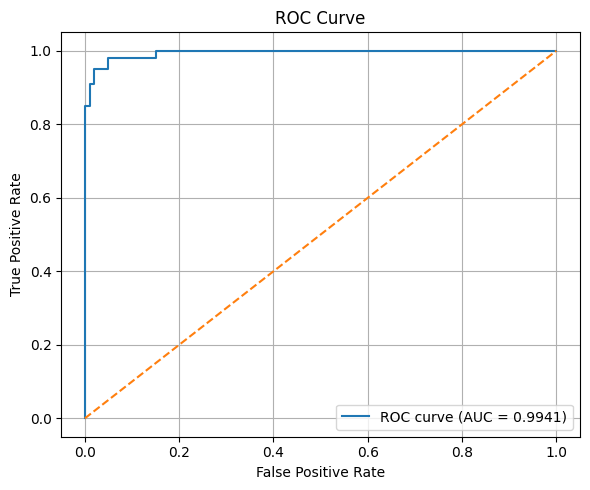

[h264 @ 0x40eb2f80] mb_type 104 in P slice too large at 98 31
[h264 @ 0x40eb2f80] error while decoding MB 98 31



=== TEST METRICS ===
Accuracy : 0.9609
Precision: 1.0000
Recall   : 0.9218
F1-score : 0.9593
ROC AUC  : 0.9993


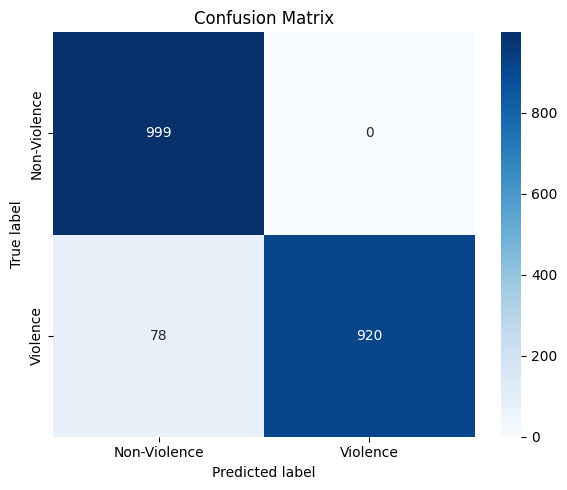

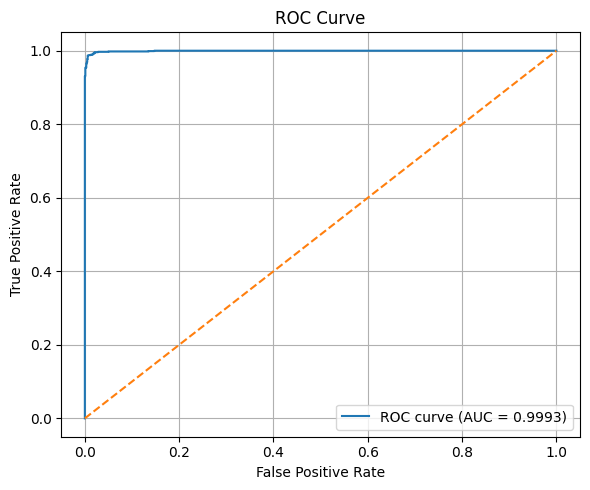


--- Scenario: Hockey_train ---

=== Seed 44 ===


Epoch 1/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9038, Val Acc: 0.9800


Epoch 2/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9625, Val Acc: 0.9600


...

Summary -> Train Acc: 0.9762, Val Acc: 0.9700


Epoch 4/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9700, Val Acc: 0.9600


Epoch 5/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9888, Val Acc: 0.9600


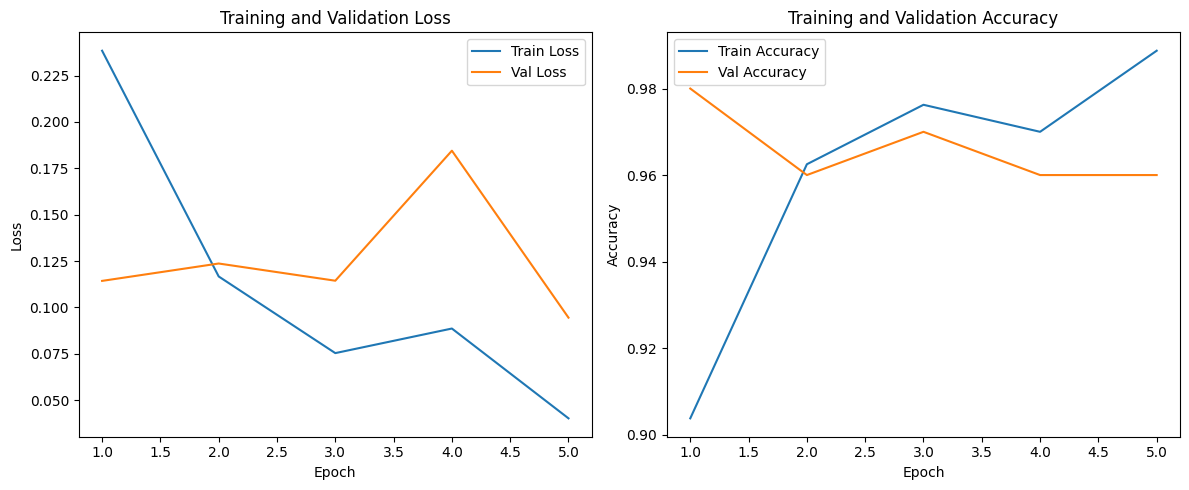


=== VAL METRICS ===
Accuracy : 0.9600
Precision: 0.9259
Recall   : 1.0000
F1-score : 0.9615
ROC AUC  : 0.9980


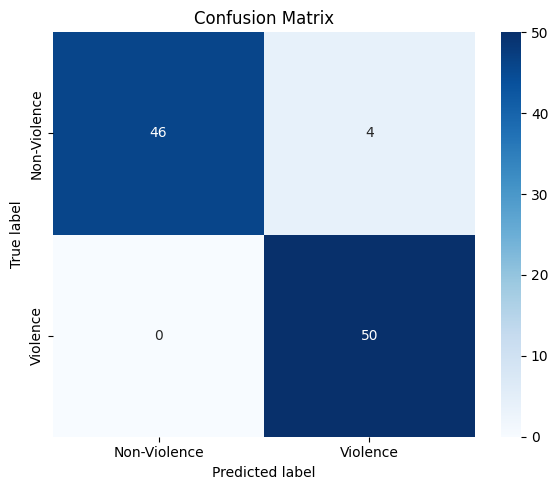

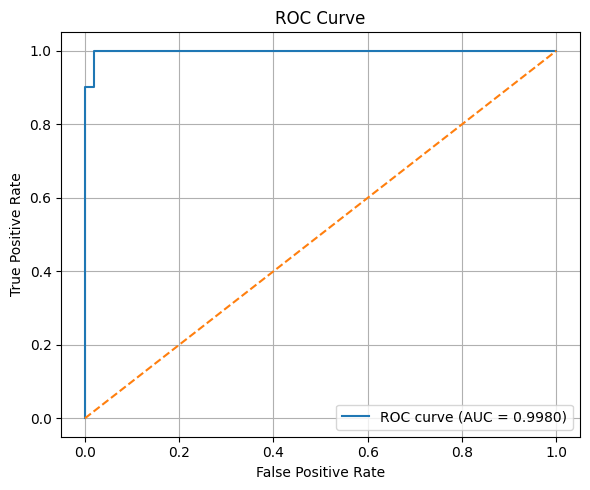


=== TEST METRICS ===
Accuracy : 0.9940
Precision: 0.9881
Recall   : 1.0000
F1-score : 0.9940
ROC AUC  : 0.9999


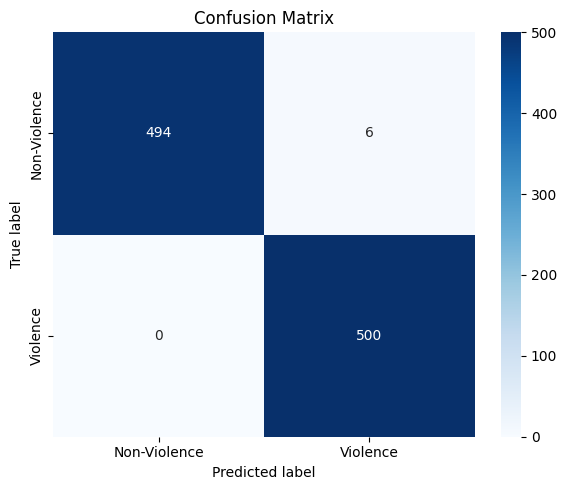

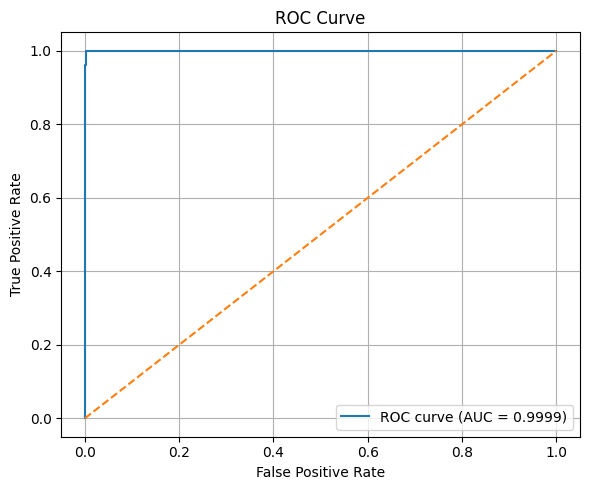


--- Scenario: RLVS_to_Hockey ---

=== Seed 44 ===


Epoch 1/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

[h264 @ 0x417fbc80] mb_type 104 in P slice too large at 98 31
[h264 @ 0x417fbc80] error while decoding MB 98 31


Summary -> Train Acc: 0.8892, Val Acc: 0.9800


Epoch 2/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

...

[h264 @ 0x4179b640] mb_type 104 in P slice too large at 98 31
[h264 @ 0x4179b640] error while decoding MB 98 31


Summary -> Train Acc: 0.9693, Val Acc: 0.9750


Epoch 5/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

[h264 @ 0x3fbad240] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3fbad240] error while decoding MB 98 31


Summary -> Train Acc: 0.9618, Val Acc: 0.9650


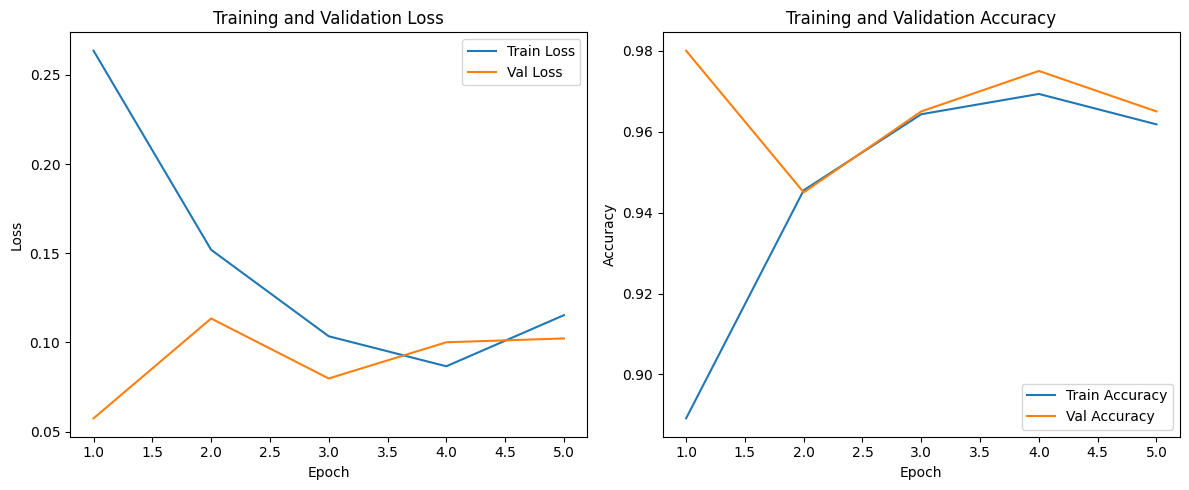


=== VAL METRICS ===
Accuracy : 0.9650
Precision: 0.9604
Recall   : 0.9700
F1-score : 0.9652
ROC AUC  : 0.9929


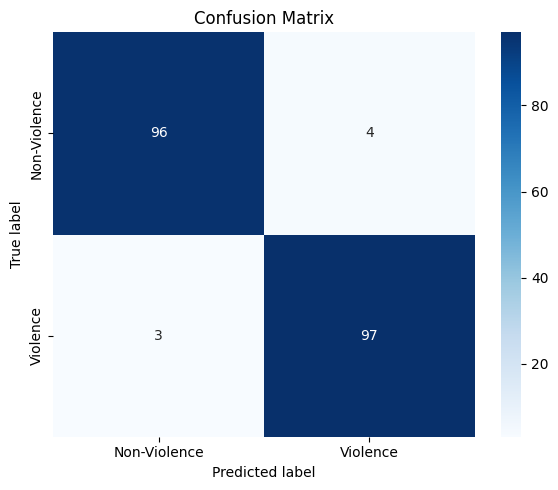

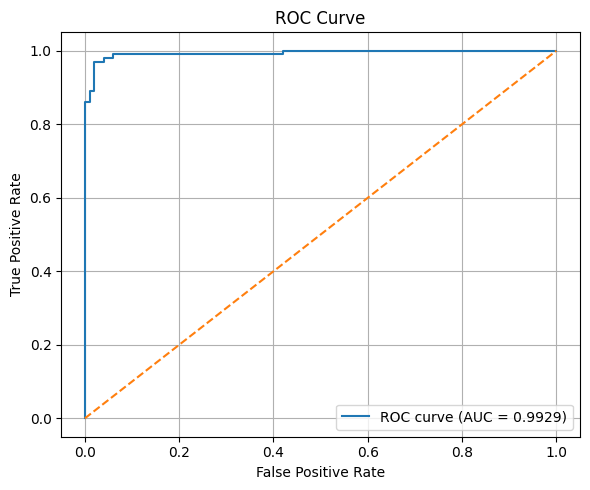


=== TEST METRICS ===
Accuracy : 0.5020
Precision: 0.5010
Recall   : 0.9980
F1-score : 0.6671
ROC AUC  : 0.9010


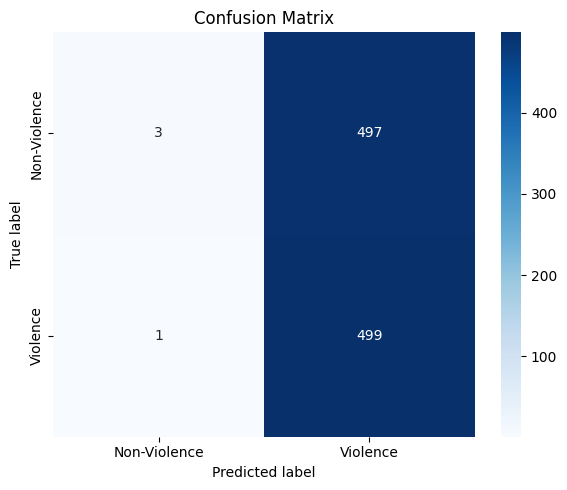

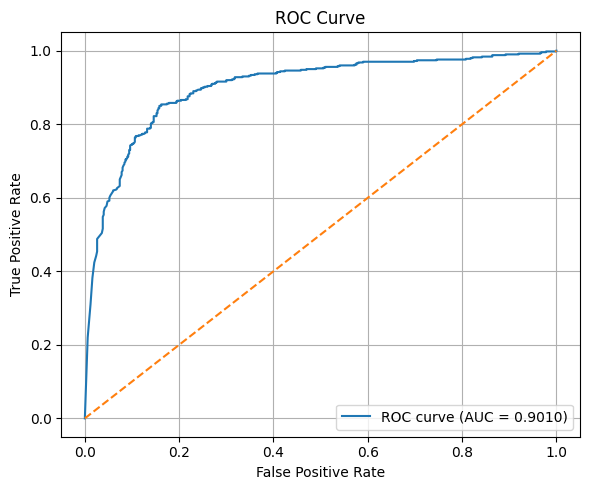


--- Scenario: Hockey_to_RLVS ---

=== Seed 44 ===


Epoch 1/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9050, Val Acc: 0.9400


Epoch 2/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9637, Val Acc: 0.9600


...

Summary -> Train Acc: 0.9775, Val Acc: 0.9600


Epoch 4/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9688, Val Acc: 0.9900


Epoch 5/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9838, Val Acc: 0.9700


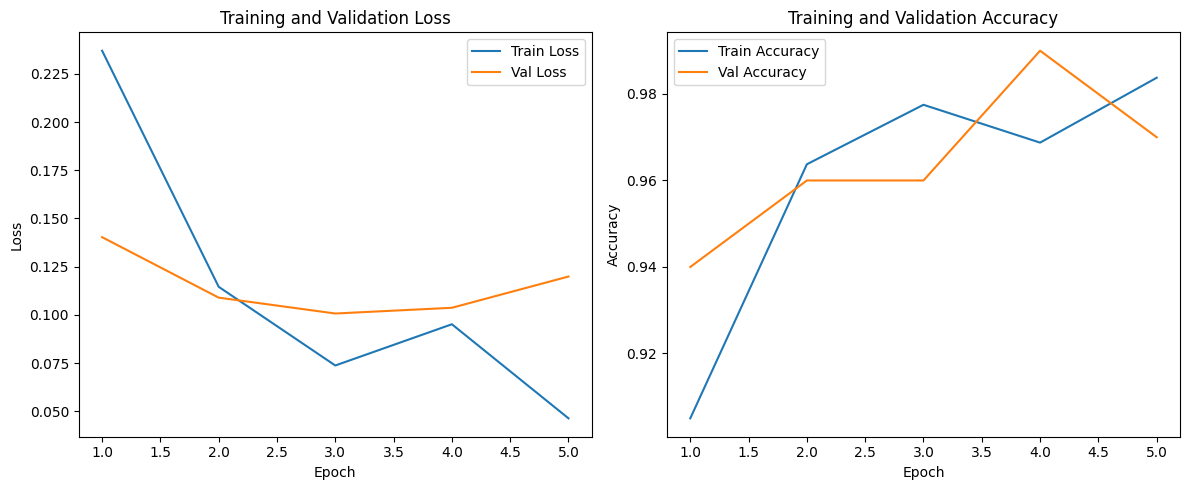


=== VAL METRICS ===
Accuracy : 0.9700
Precision: 0.9434
Recall   : 1.0000
F1-score : 0.9709
ROC AUC  : 0.9908


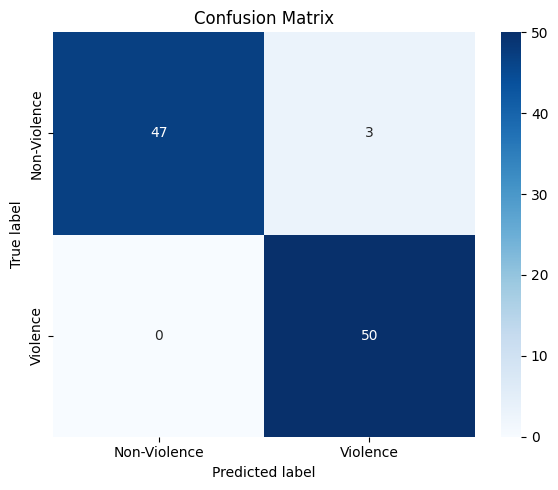

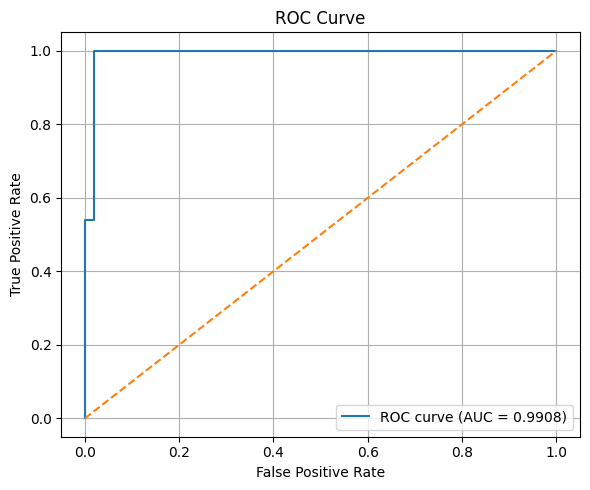

[h264 @ 0x41f2b000] mb_type 104 in P slice too large at 98 31
[h264 @ 0x41f2b000] error while decoding MB 98 31



=== TEST METRICS ===
Accuracy : 0.5759
Precision: 0.5511
Recall   : 0.8156
F1-score : 0.6578
ROC AUC  : 0.6590


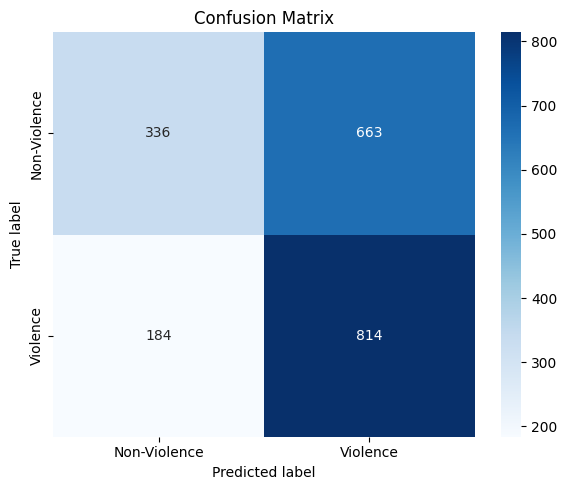

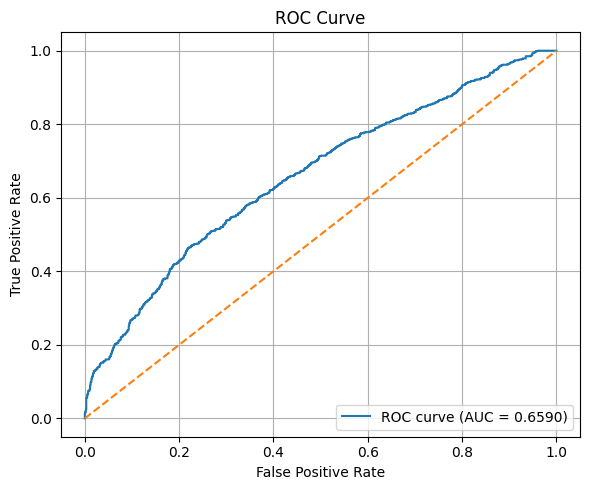


--- Scenario: Combined_RLVS_Hockey_to_SCVD ---

=== Seed 44 ===


Epoch 1/5 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

[h264 @ 0x4243b5c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x4243b5c0] error while decoding MB 98 31


Summary -> Train Acc: 0.8878, Val Acc: 0.9100


Epoch 2/5 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

...

[h264 @ 0x424e03c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x424e03c0] error while decoding MB 98 31


Summary -> Train Acc: 0.9733, Val Acc: 0.9667


Epoch 5/5 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

[h264 @ 0x3fbb0180] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3fbb0180] error while decoding MB 98 31


Summary -> Train Acc: 0.9645, Val Acc: 0.9833


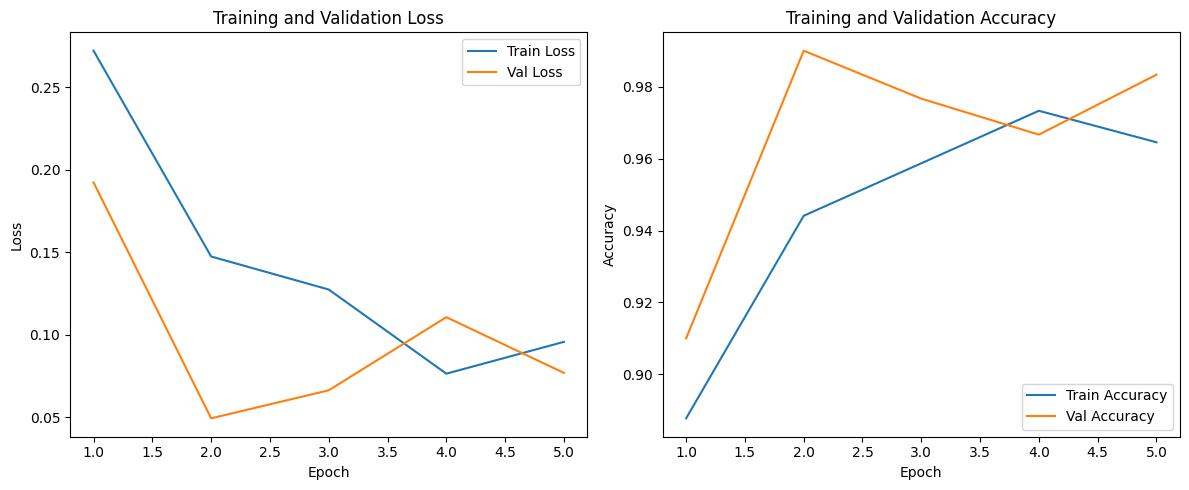


=== VAL METRICS ===
Accuracy : 0.9833
Precision: 0.9677
Recall   : 1.0000
F1-score : 0.9836
ROC AUC  : 0.9956


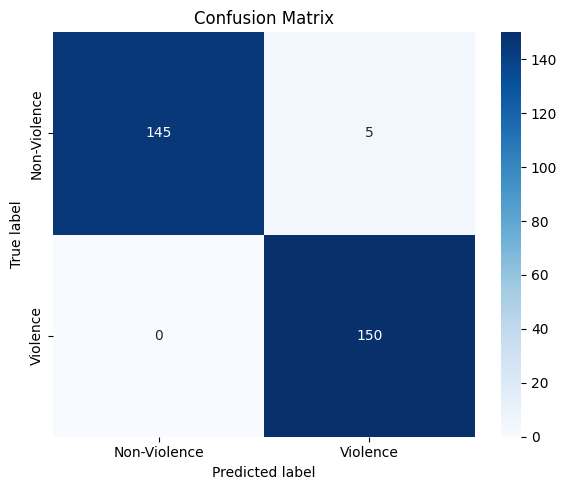

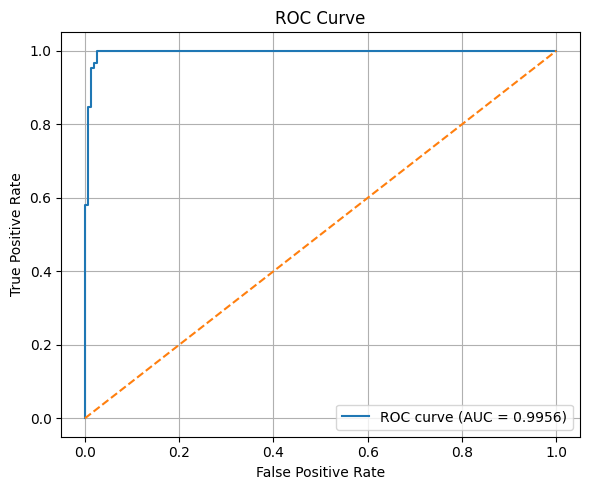


=== TEST METRICS ===
Accuracy : 0.7561
Precision: 0.7000
Recall   : 0.7778
F1-score : 0.7368
ROC AUC  : 0.8285


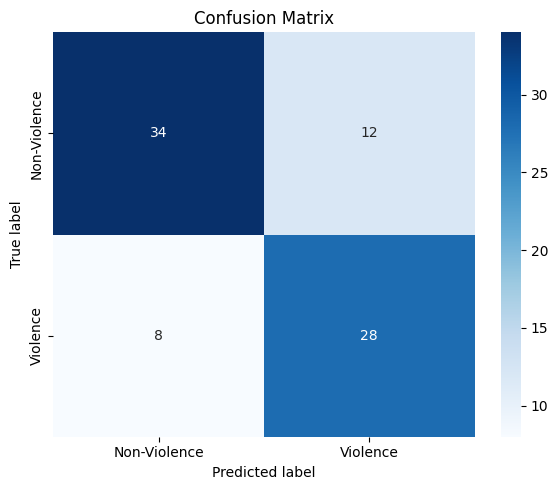

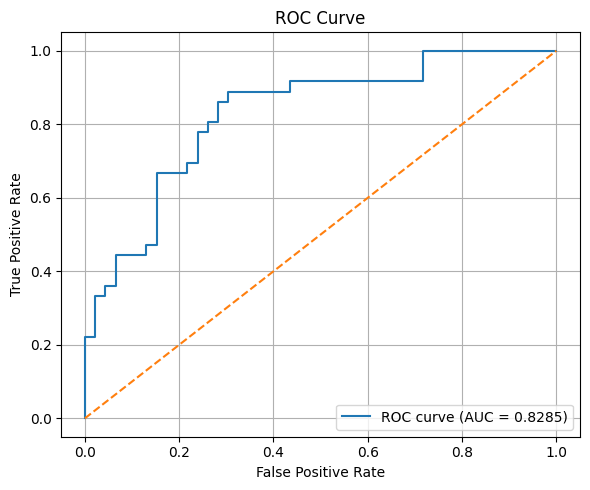



========== MODEL: mobilenet_v2 ==========

--- Scenario: RLVS_train ---

=== Seed 44 ===
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 230MB/s]


Epoch 1/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

[h264 @ 0x3f92e0c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3f92e0c0] error while decoding MB 98 31


Summary -> Train Acc: 0.8647, Val Acc: 0.9650


...

[h264 @ 0x43350c40] mb_type 104 in P slice too large at 98 31
[h264 @ 0x43350c40] error while decoding MB 98 31


Summary -> Train Acc: 0.9743, Val Acc: 0.9850


Epoch 5/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

[h264 @ 0x432526c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x432526c0] error while decoding MB 98 31


Summary -> Train Acc: 0.9862, Val Acc: 0.9850


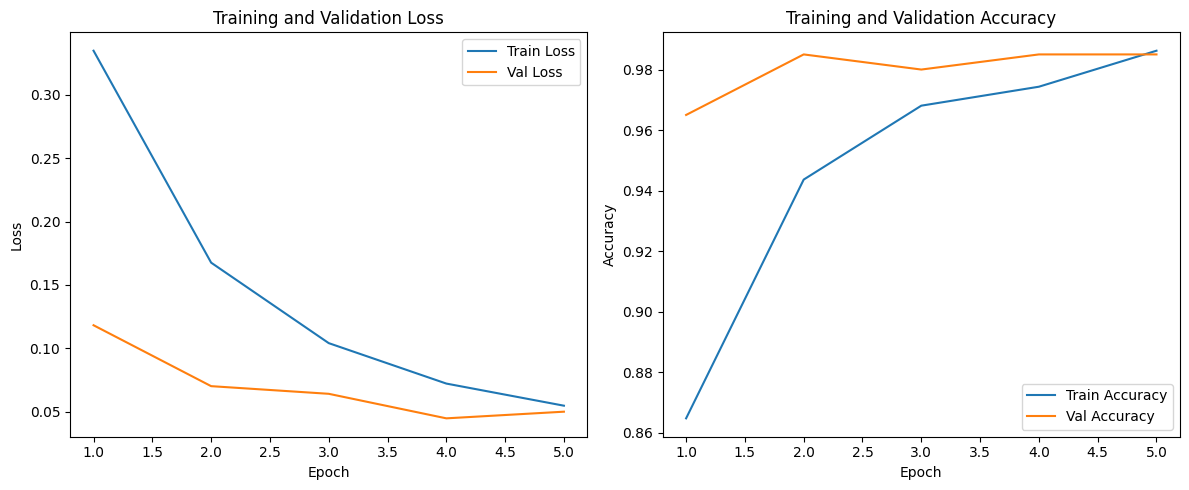


=== VAL METRICS ===
Accuracy : 0.9850
Precision: 0.9899
Recall   : 0.9800
F1-score : 0.9849
ROC AUC  : 0.9986


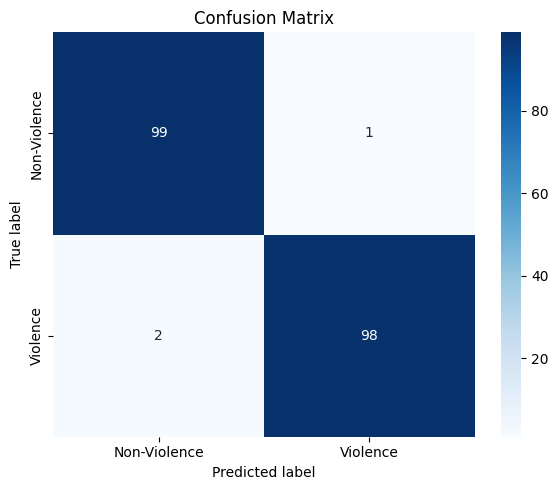

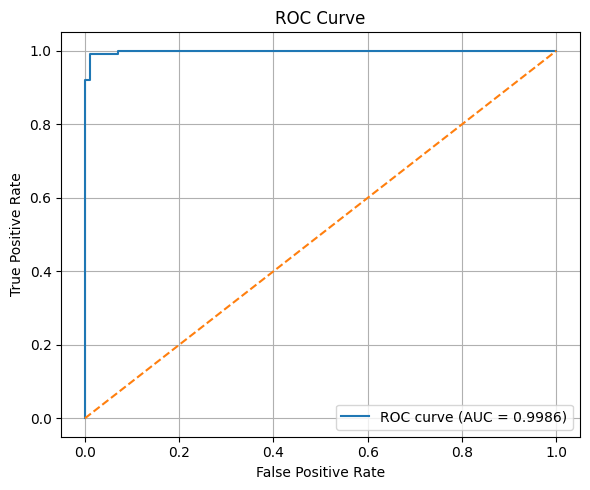

[h264 @ 0x43f2d200] mb_type 104 in P slice too large at 98 31
[h264 @ 0x43f2d200] error while decoding MB 98 31



=== TEST METRICS ===
Accuracy : 0.9930
Precision: 0.9940
Recall   : 0.9920
F1-score : 0.9930
ROC AUC  : 0.9993


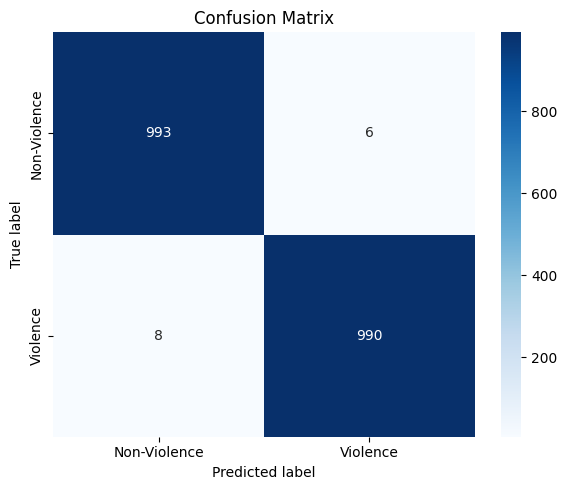

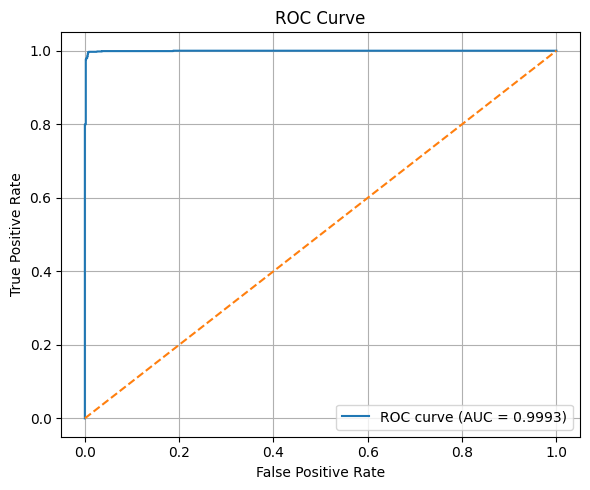


--- Scenario: Hockey_train ---

=== Seed 44 ===


Epoch 1/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.8650, Val Acc: 0.9300


Epoch 2/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9500, Val Acc: 0.9500


...

Summary -> Train Acc: 0.9800, Val Acc: 0.9600


Epoch 4/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9788, Val Acc: 0.9700


Epoch 5/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9925, Val Acc: 0.9400


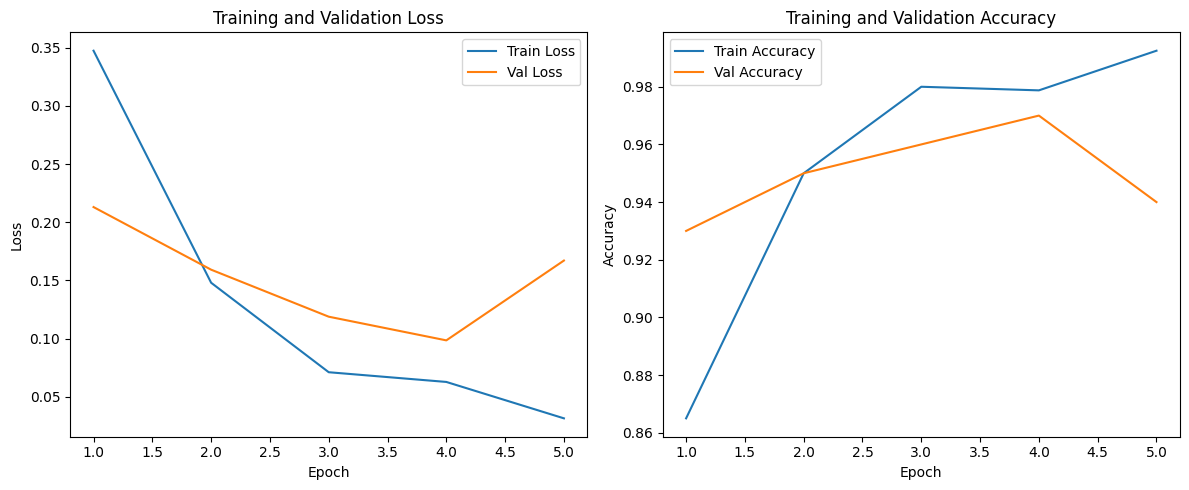


=== VAL METRICS ===
Accuracy : 0.9400
Precision: 0.8929
Recall   : 1.0000
F1-score : 0.9434
ROC AUC  : 0.9984


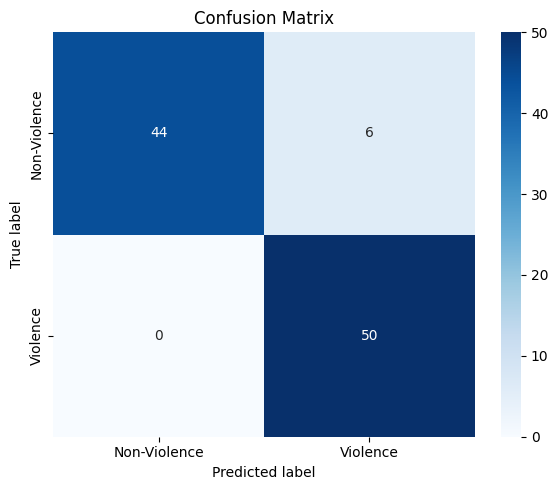

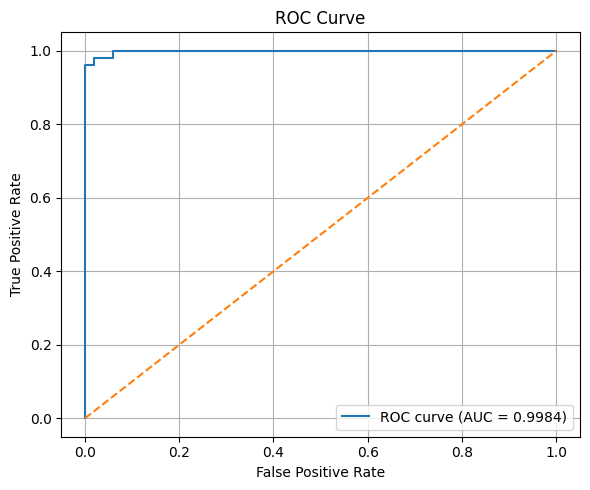


=== TEST METRICS ===
Accuracy : 0.9920
Precision: 0.9843
Recall   : 1.0000
F1-score : 0.9921
ROC AUC  : 0.9998


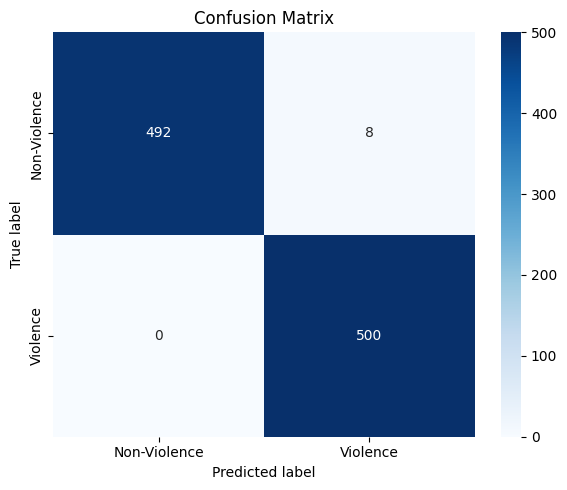

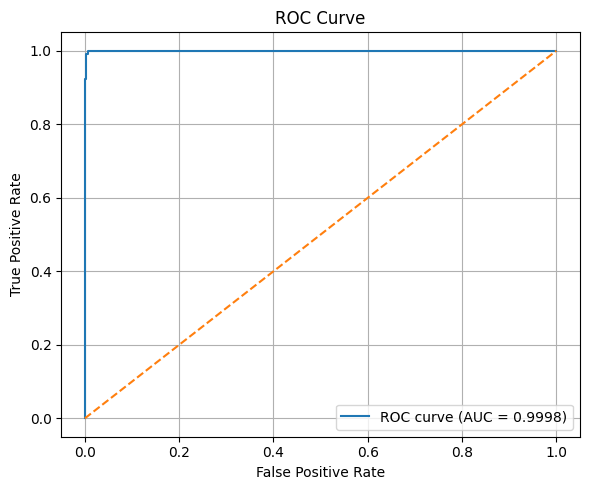


--- Scenario: RLVS_to_Hockey ---

=== Seed 44 ===


Epoch 1/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

[h264 @ 0x3bd86580] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3bd86580] error while decoding MB 98 31


Summary -> Train Acc: 0.8647, Val Acc: 0.9600


Epoch 2/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

...

[h264 @ 0x417c6880] mb_type 104 in P slice too large at 98 31
[h264 @ 0x417c6880] error while decoding MB 98 31


Summary -> Train Acc: 0.9768, Val Acc: 0.9850


Epoch 5/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

[h264 @ 0x42414380] mb_type 104 in P slice too large at 98 31
[h264 @ 0x42414380] error while decoding MB 98 31


Summary -> Train Acc: 0.9869, Val Acc: 0.9850


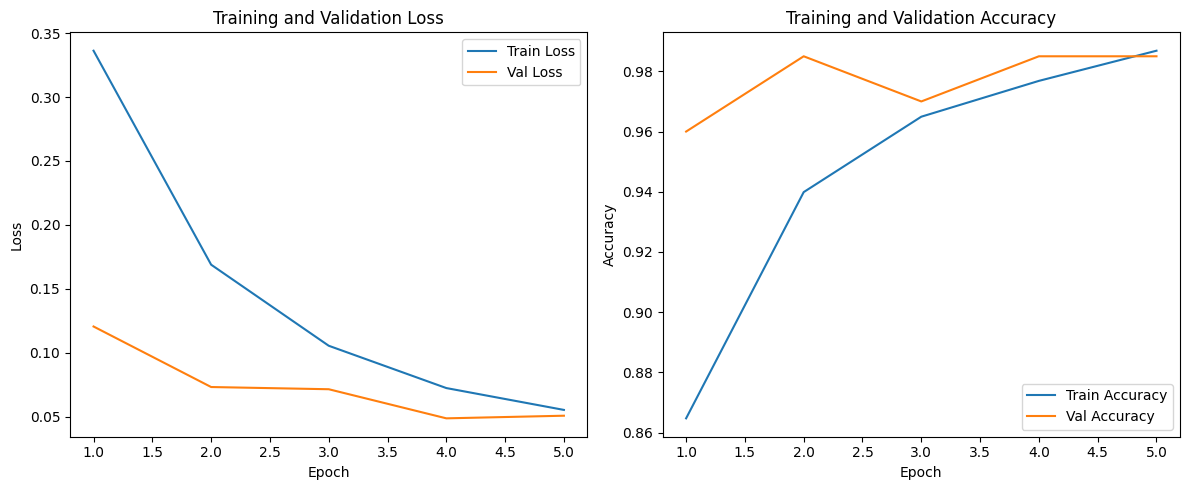


=== VAL METRICS ===
Accuracy : 0.9850
Precision: 0.9899
Recall   : 0.9800
F1-score : 0.9849
ROC AUC  : 0.9986


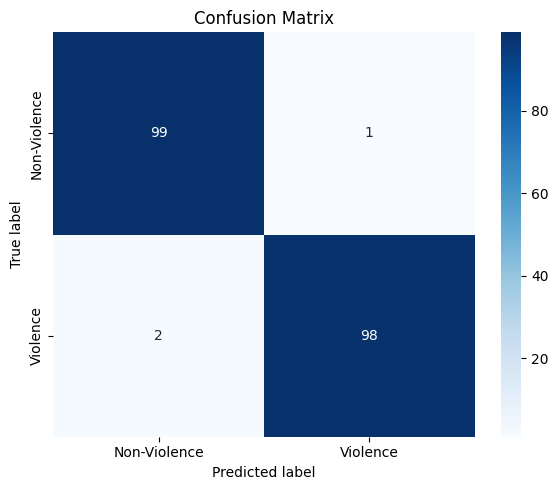

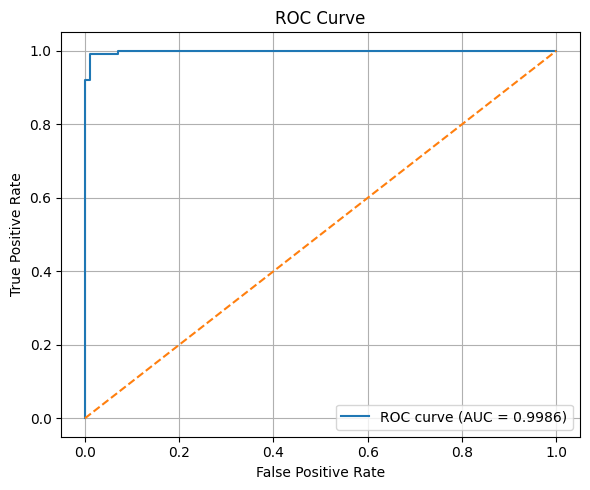


=== TEST METRICS ===
Accuracy : 0.5420
Precision: 0.5221
Recall   : 0.9940
F1-score : 0.6846
ROC AUC  : 0.8820


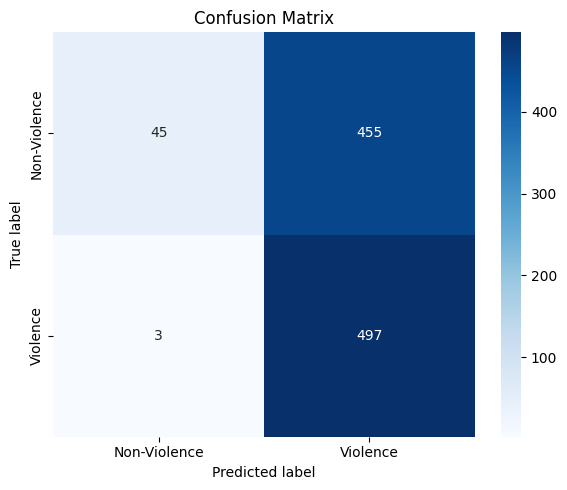

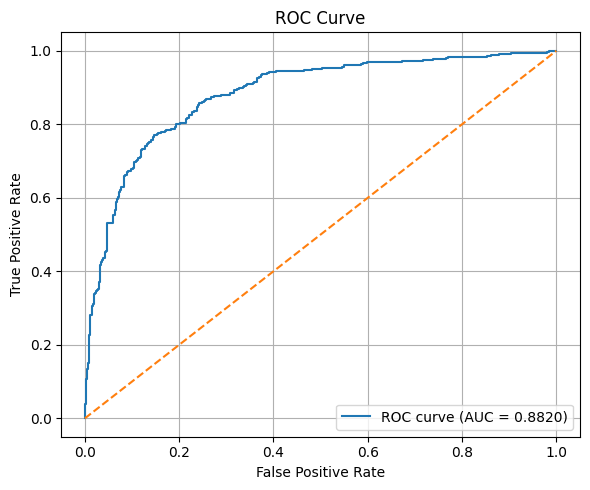


--- Scenario: Hockey_to_RLVS ---

=== Seed 44 ===


Epoch 1/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.8650, Val Acc: 0.9400


Epoch 2/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9513, Val Acc: 0.9500


...

Epoch 4/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x788cd998cfe0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x788cd998cfe0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Summary -> Train Acc: 0.9825, Val Acc: 0.9600


Epoch 5/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9912, Val Acc: 0.9400


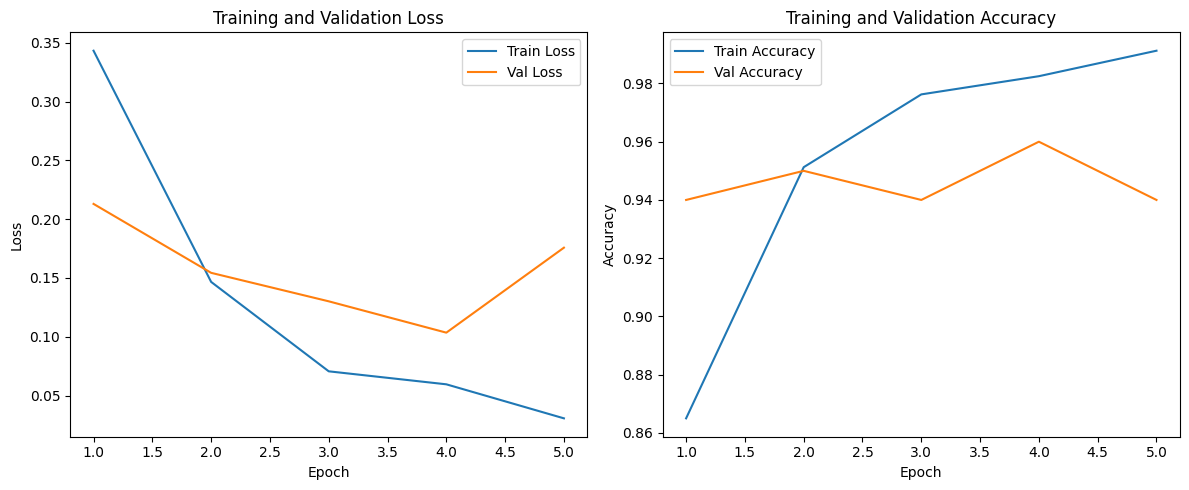


=== VAL METRICS ===
Accuracy : 0.9400
Precision: 0.8929
Recall   : 1.0000
F1-score : 0.9434
ROC AUC  : 0.9992


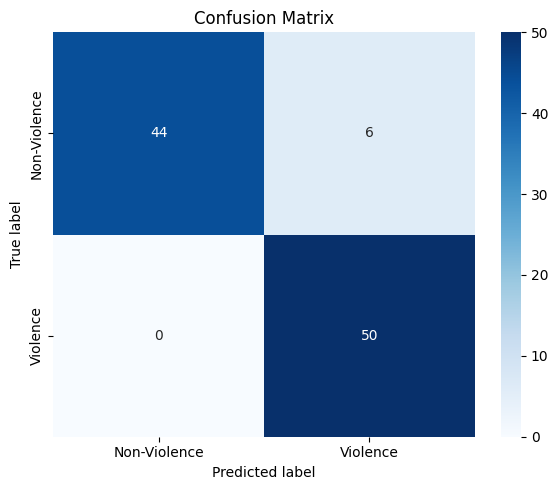

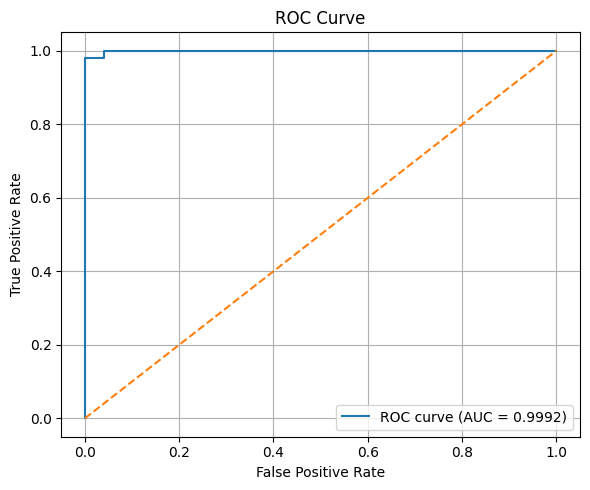

[h264 @ 0x429ebf00] mb_type 104 in P slice too large at 98 31
[h264 @ 0x429ebf00] error while decoding MB 98 31



=== TEST METRICS ===
Accuracy : 0.5478
Precision: 0.5273
Recall   : 0.9188
F1-score : 0.6701
ROC AUC  : 0.7814


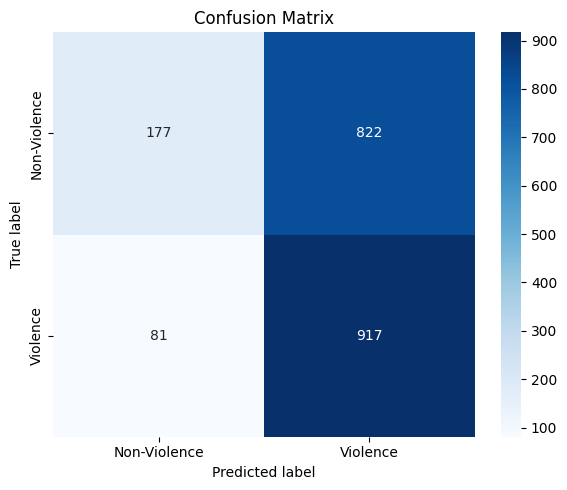

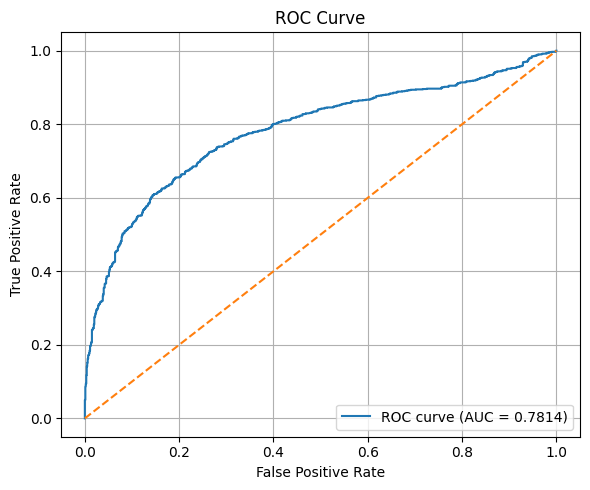


--- Scenario: Combined_RLVS_Hockey_to_SCVD ---

=== Seed 44 ===


Epoch 1/5 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

[h264 @ 0x430e3ec0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x430e3ec0] error while decoding MB 98 31


Summary -> Train Acc: 0.8769, Val Acc: 0.9600


Epoch 2/5 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

...

[h264 @ 0x416f2bc0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x416f2bc0] error while decoding MB 98 31


Summary -> Train Acc: 0.9754, Val Acc: 0.9800


Epoch 5/5 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x788cd998cfe0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x788cd998cfe0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Summary -> Train Acc: 0.9716, Val Acc: 0.9933


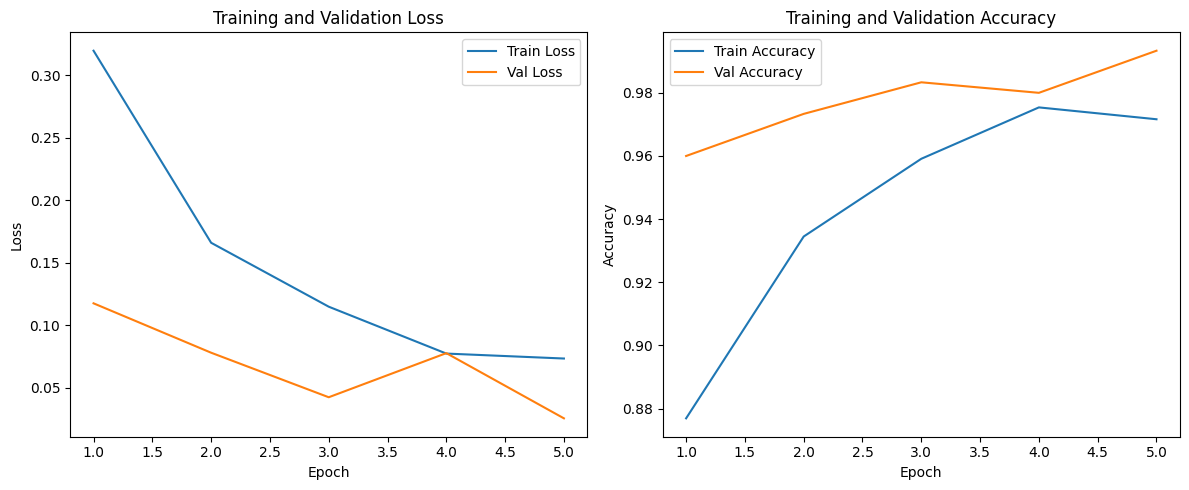


=== VAL METRICS ===
Accuracy : 0.9933
Precision: 1.0000
Recall   : 0.9867
F1-score : 0.9933
ROC AUC  : 0.9999


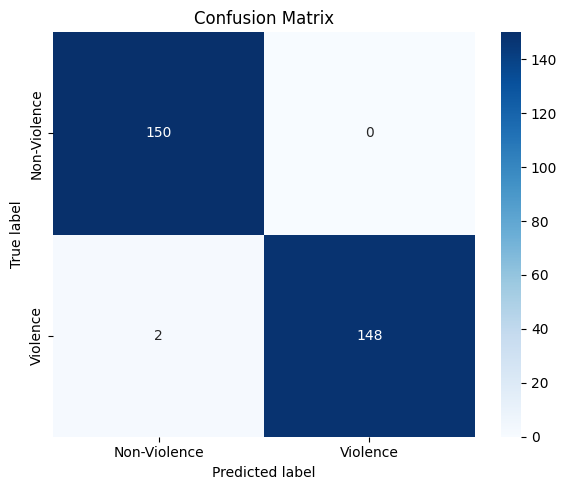

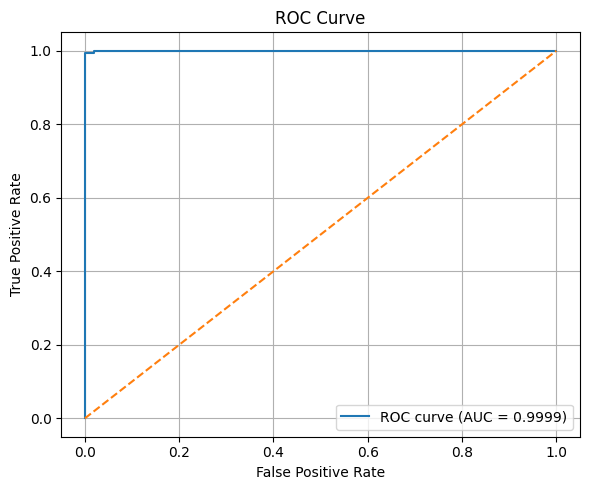


=== TEST METRICS ===
Accuracy : 0.7805
Precision: 0.7250
Recall   : 0.8056
F1-score : 0.7632
ROC AUC  : 0.8979


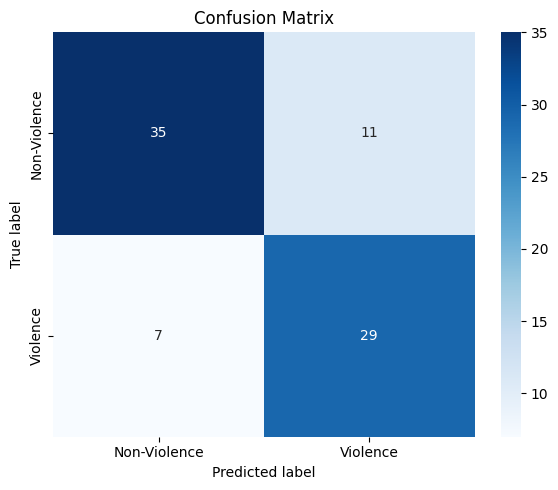

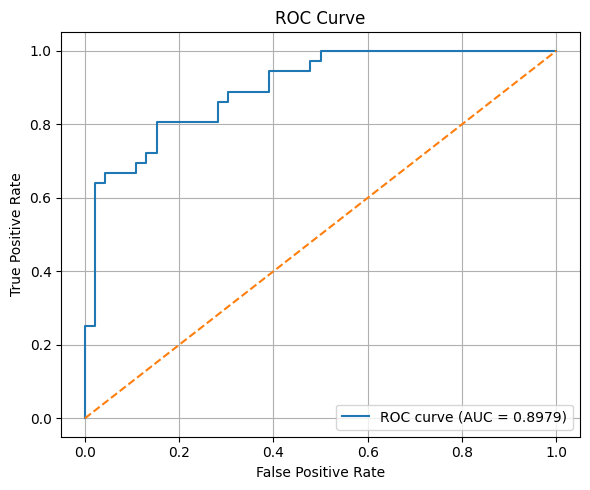



========== MODEL: efficientnet_b0 ==========

--- Scenario: RLVS_train ---

=== Seed 44 ===
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 190MB/s]


Epoch 1/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x788cd998cfe0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x788cd998cfe0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Summary -> Train Acc: 0.8635, Val Acc: 0.9750


...

[h264 @ 0x418b2680] mb_type 104 in P slice too large at 98 31
[h264 @ 0x418b2680] error while decoding MB 98 31


Summary -> Train Acc: 0.9818, Val Acc: 0.9850


Epoch 5/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

[h264 @ 0x423fa700] mb_type 104 in P slice too large at 98 31
[h264 @ 0x423fa700] error while decoding MB 98 31


Summary -> Train Acc: 0.9831, Val Acc: 0.9750


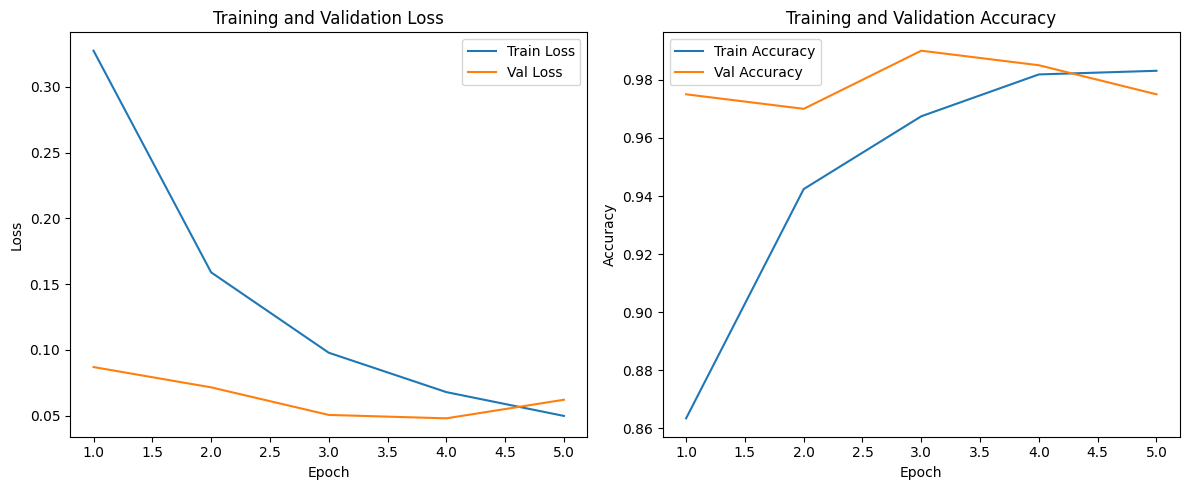


=== VAL METRICS ===
Accuracy : 0.9750
Precision: 0.9612
Recall   : 0.9900
F1-score : 0.9754
ROC AUC  : 0.9989


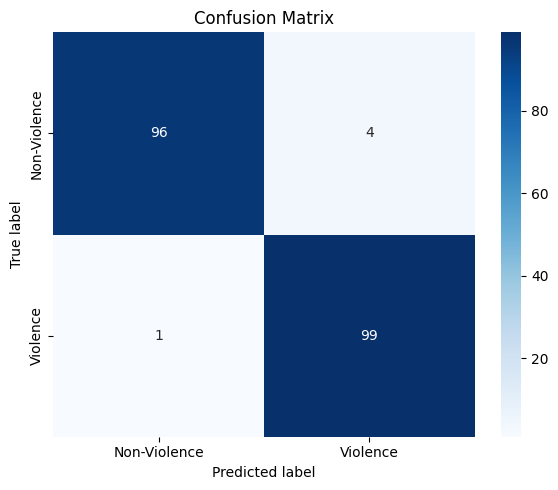

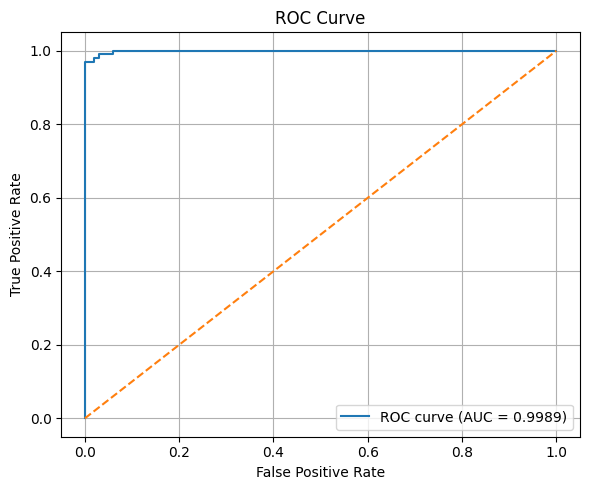

[h264 @ 0x4c5a41c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x4c5a41c0] error while decoding MB 98 31



=== TEST METRICS ===
Accuracy : 0.9935
Precision: 0.9900
Recall   : 0.9970
F1-score : 0.9935
ROC AUC  : 0.9999


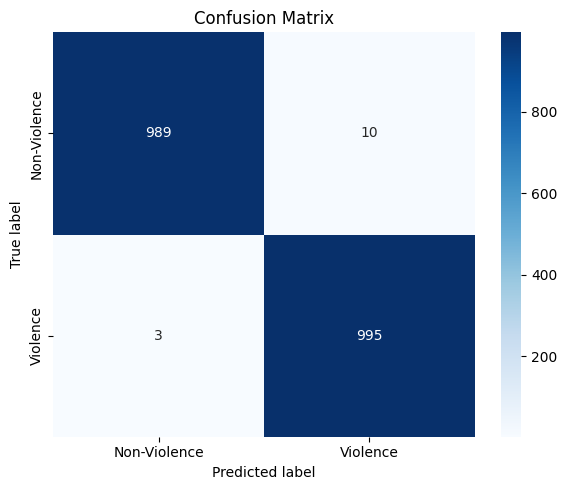

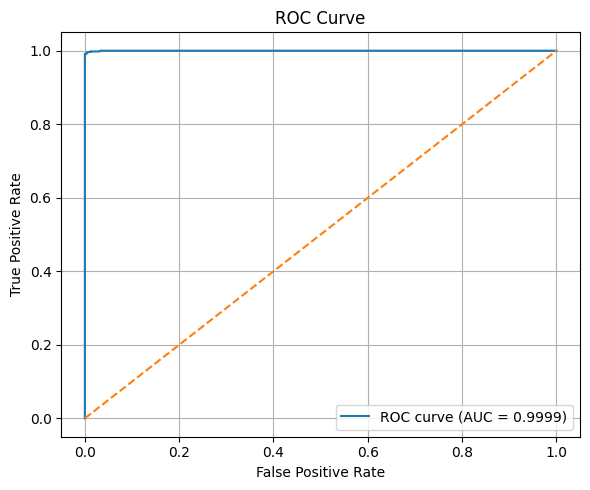


--- Scenario: Hockey_train ---

=== Seed 44 ===


Epoch 1/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9038, Val Acc: 0.9400


Epoch 2/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9363, Val Acc: 0.9500


...

Summary -> Train Acc: 0.9825, Val Acc: 0.9600


Epoch 4/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9850, Val Acc: 0.9500


Epoch 5/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9825, Val Acc: 0.9500


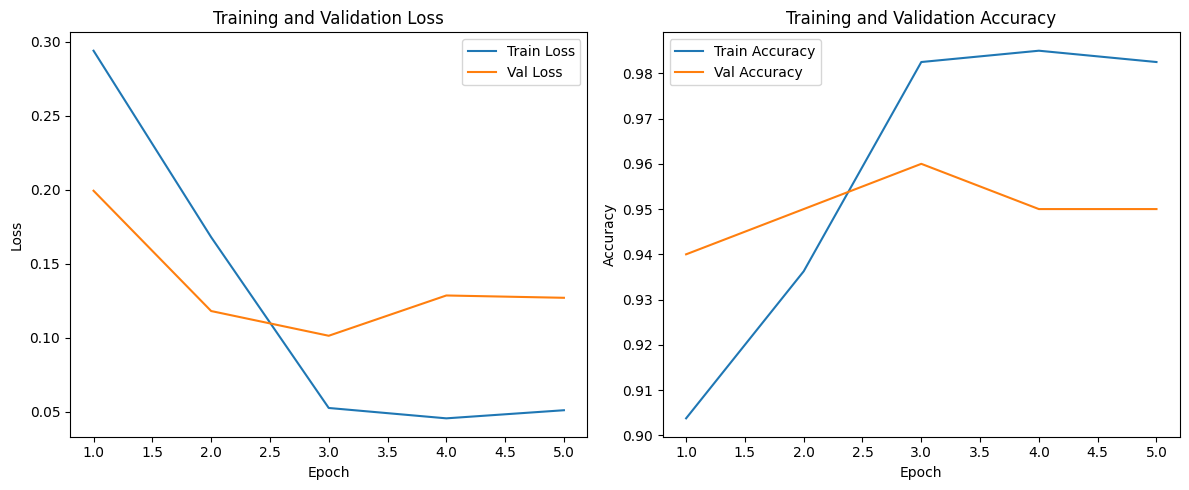


=== VAL METRICS ===
Accuracy : 0.9500
Precision: 0.9091
Recall   : 1.0000
F1-score : 0.9524
ROC AUC  : 0.9968


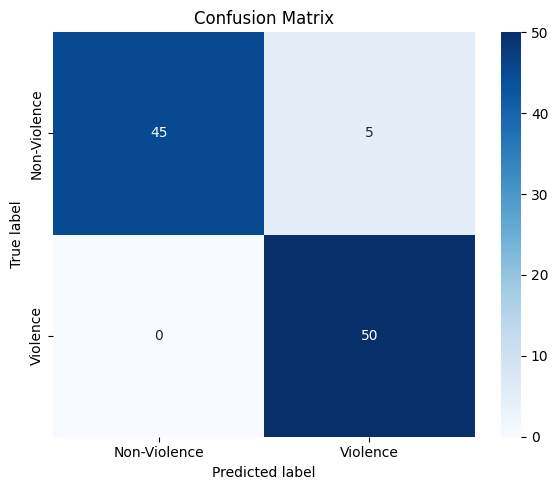

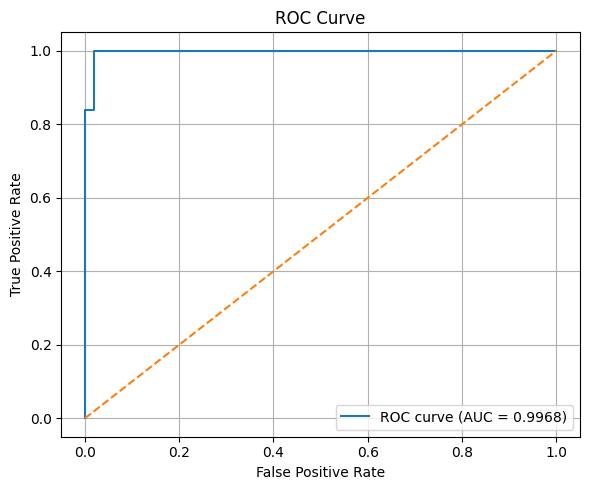


=== TEST METRICS ===
Accuracy : 0.9950
Precision: 0.9901
Recall   : 1.0000
F1-score : 0.9950
ROC AUC  : 0.9997


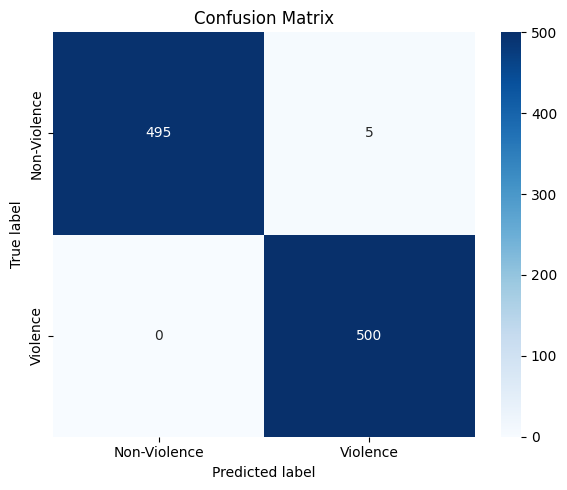

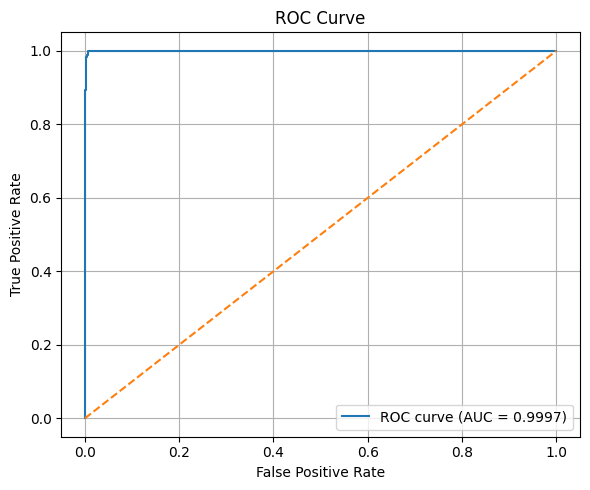


--- Scenario: RLVS_to_Hockey ---

=== Seed 44 ===


Epoch 1/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

[h264 @ 0x4363e0c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x4363e0c0] error while decoding MB 98 31


Summary -> Train Acc: 0.8635, Val Acc: 0.9750


Epoch 2/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

...

[h264 @ 0x432e6400] mb_type 104 in P slice too large at 98 31
[h264 @ 0x432e6400] error while decoding MB 98 31


Summary -> Train Acc: 0.9818, Val Acc: 0.9850


Epoch 5/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

[h264 @ 0x41bde300] mb_type 104 in P slice too large at 98 31
[h264 @ 0x41bde300] error while decoding MB 98 31


Summary -> Train Acc: 0.9843, Val Acc: 0.9750


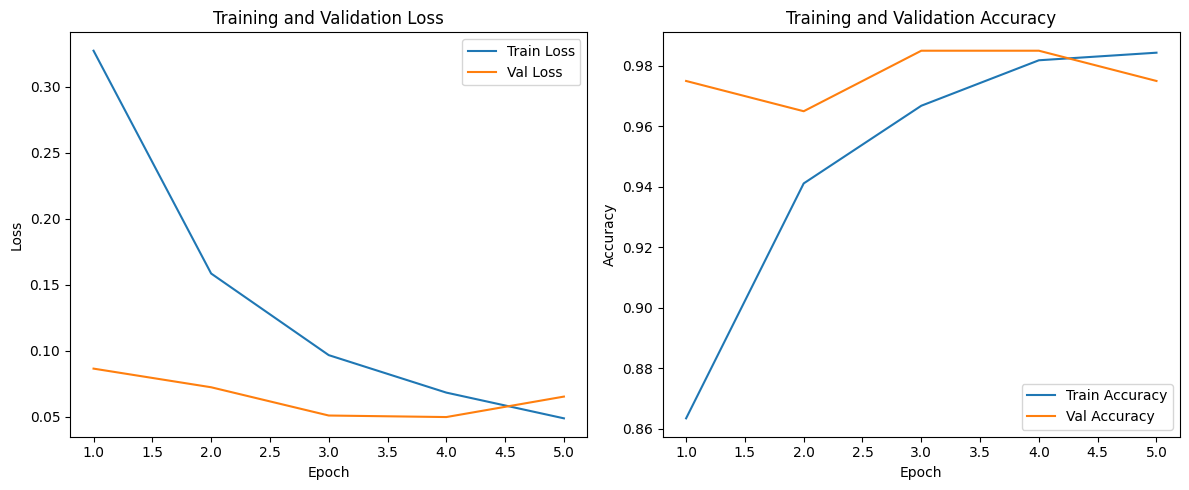


=== VAL METRICS ===
Accuracy : 0.9750
Precision: 0.9612
Recall   : 0.9900
F1-score : 0.9754
ROC AUC  : 0.9981


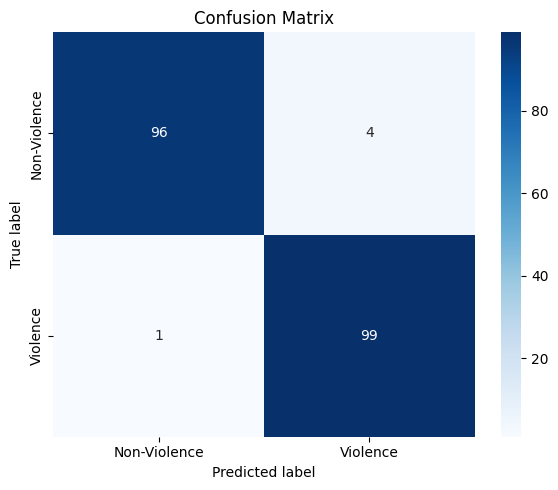

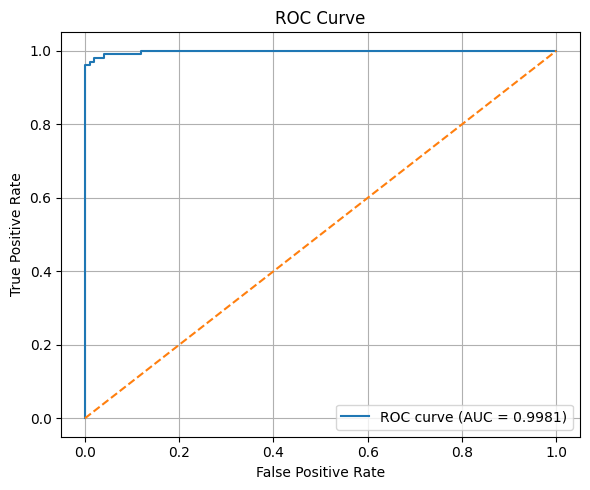


=== TEST METRICS ===
Accuracy : 0.6230
Precision: 0.5708
Recall   : 0.9920
F1-score : 0.7246
ROC AUC  : 0.9153


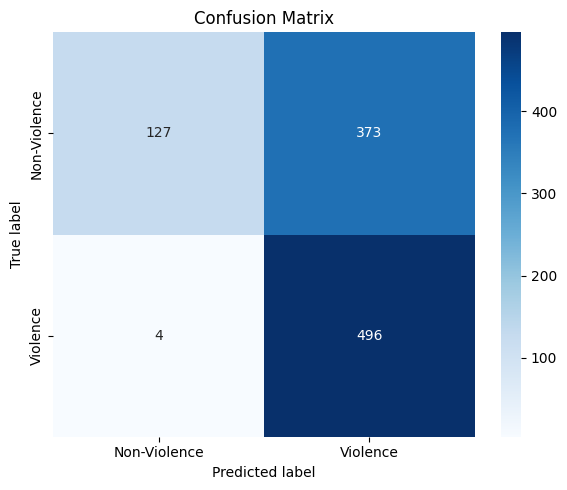

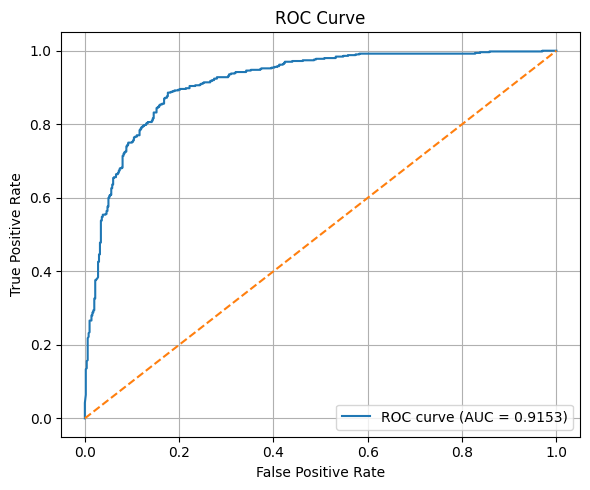


--- Scenario: Hockey_to_RLVS ---

=== Seed 44 ===


Epoch 1/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9038, Val Acc: 0.9400


Epoch 2/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9387, Val Acc: 0.9500


...

Summary -> Train Acc: 0.9825, Val Acc: 0.9600


Epoch 4/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9850, Val Acc: 0.9500


Epoch 5/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9838, Val Acc: 0.9500


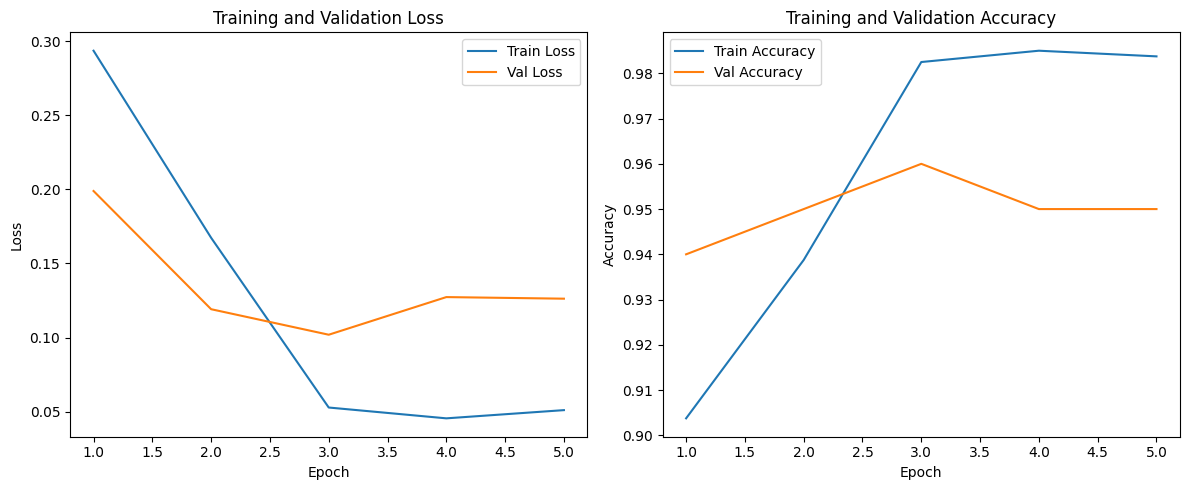


=== VAL METRICS ===
Accuracy : 0.9500
Precision: 0.9091
Recall   : 1.0000
F1-score : 0.9524
ROC AUC  : 0.9960


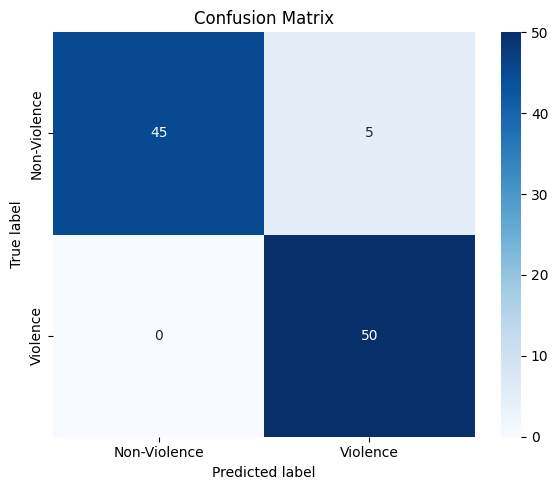

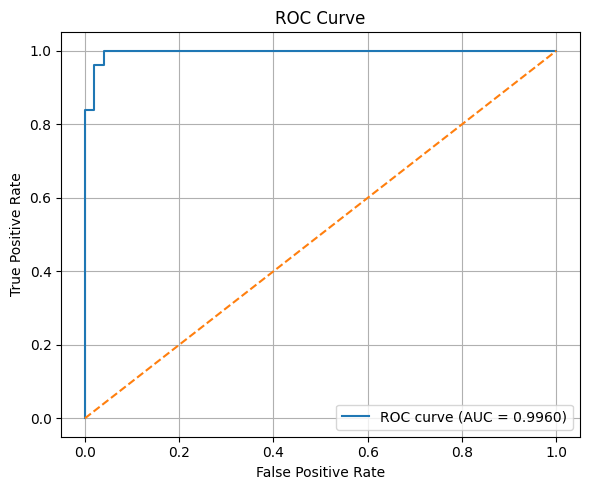

[h264 @ 0x41b98040] mb_type 104 in P slice too large at 98 31
[h264 @ 0x41b98040] error while decoding MB 98 31



=== TEST METRICS ===
Accuracy : 0.6970
Precision: 0.6534
Recall   : 0.8387
F1-score : 0.7345
ROC AUC  : 0.8016


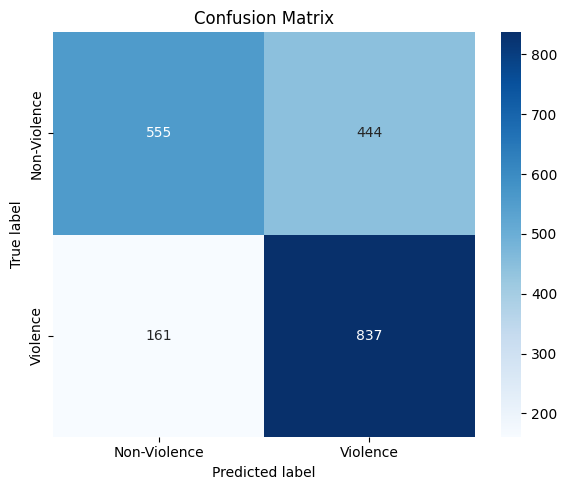

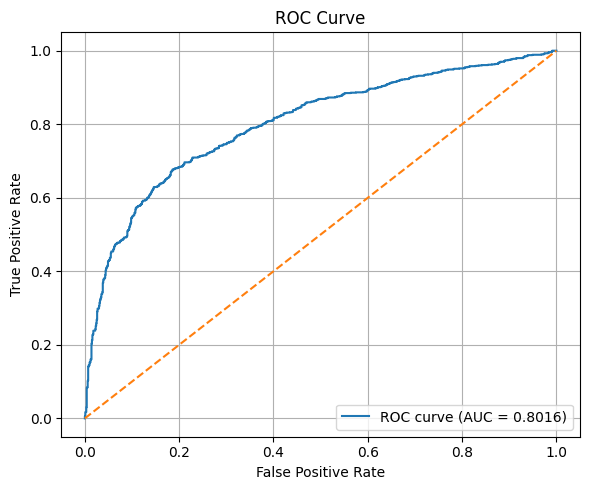


--- Scenario: Combined_RLVS_Hockey_to_SCVD ---

=== Seed 44 ===


Epoch 1/5 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

[h264 @ 0x41b43a00] mb_type 104 in P slice too large at 98 31
[h264 @ 0x41b43a00] error while decoding MB 98 31


Summary -> Train Acc: 0.8869, Val Acc: 0.9567


Epoch 2/5 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

...

[h264 @ 0x42f84e80] mb_type 104 in P slice too large at 98 31
[h264 @ 0x42f84e80] error while decoding MB 98 31


Summary -> Train Acc: 0.9800, Val Acc: 0.9833


Epoch 5/5 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

[h264 @ 0x2f0fdc80] mb_type 104 in P slice too large at 98 31
[h264 @ 0x2f0fdc80] error while decoding MB 98 31


Summary -> Train Acc: 0.9833, Val Acc: 0.9933


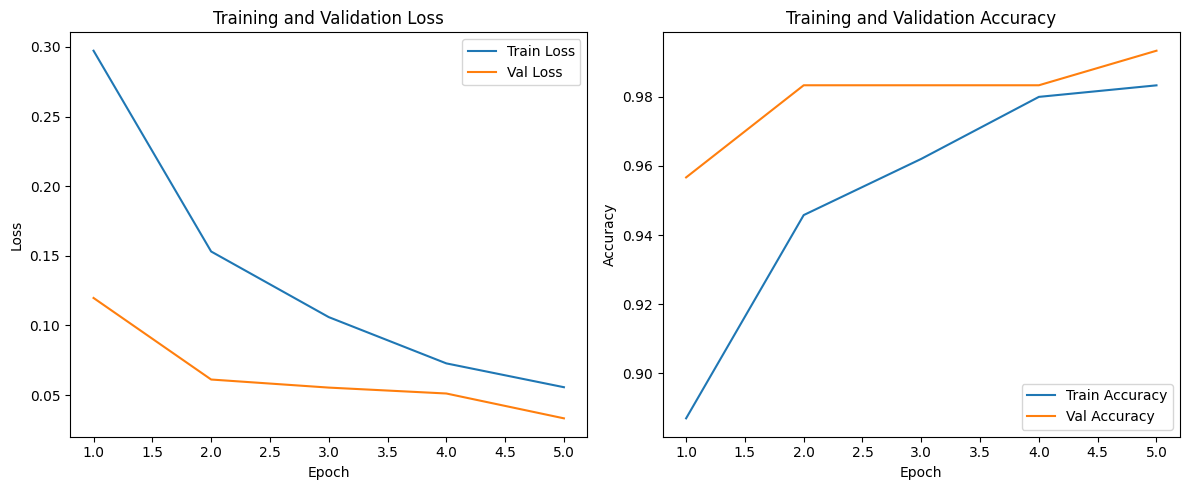


=== VAL METRICS ===
Accuracy : 0.9933
Precision: 0.9933
Recall   : 0.9933
F1-score : 0.9933
ROC AUC  : 0.9996


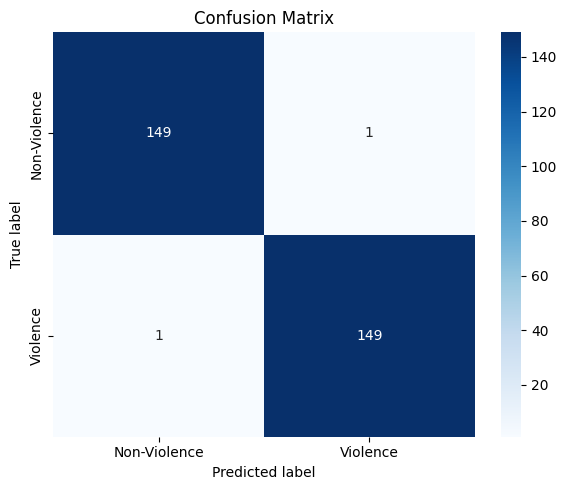

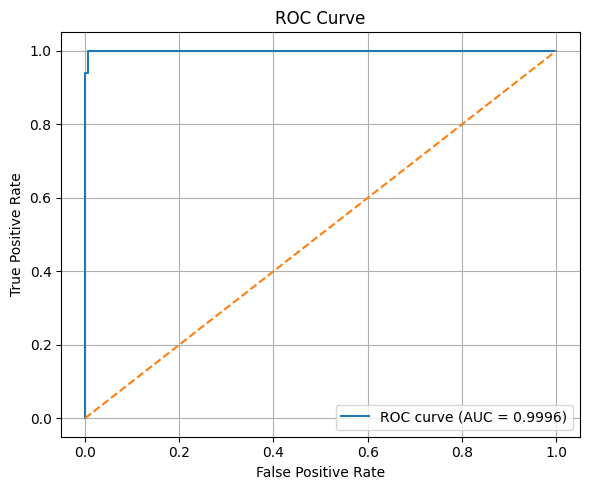


=== TEST METRICS ===
Accuracy : 0.8049
Precision: 0.8846
Recall   : 0.6389
F1-score : 0.7419
ROC AUC  : 0.8182


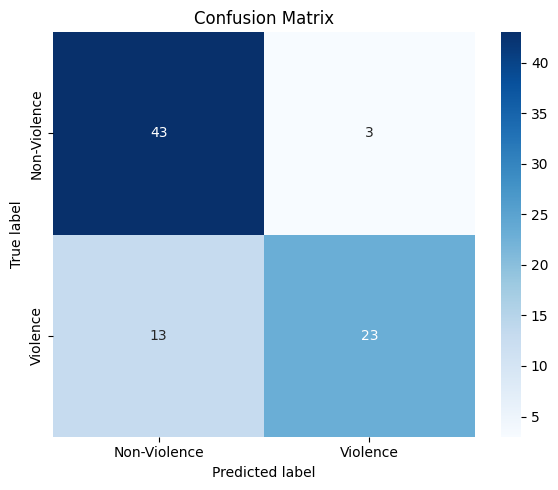

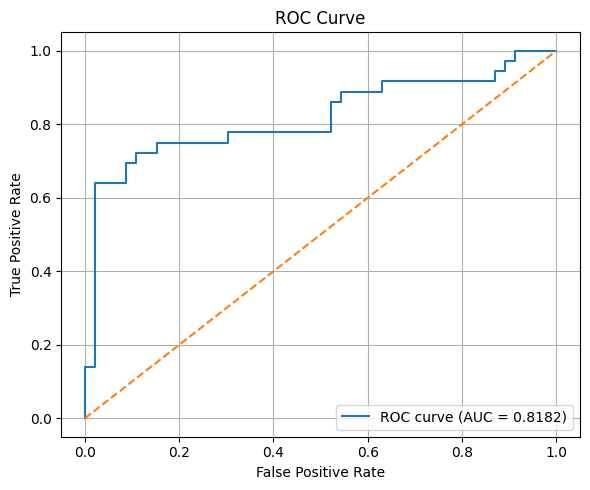

NameError: name 'StratifiedKFold' is not defined

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_names = ["resnet18","mobilenet_v2","efficientnet_b0"]
seeds = [44]
n_frames = 8
batch_size = 8

scenarios = [
    {"name": "RLVS_train", "train": ["rlvs"], "test": "rlvs"},
    {"name": "Hockey_train", "train": ["hockey"], "test": "hockey"},
    {"name": "RLVS_to_Hockey", "train": ["rlvs"], "test": "hockey"},
    {"name": "Hockey_to_RLVS", "train": ["hockey"], "test": "rlvs"},
    {"name": "Combined_RLVS_Hockey_to_SCVD", "train": ["rlvs","hockey"], "test": "scvd"},
]

all_results = {}
for model_name in model_names:
    print(f"\n\n========== MODEL: {model_name} ==========")
    for scenario in scenarios:
        scenario_name = scenario["name"]
        train_datasets = scenario["train"]
        test_dataset = scenario["test"]
        print(f"\n--- Scenario: {scenario_name} ---")
        
        results = run_scenario(
            model_name=model_name,
            train_datasets=train_datasets,
            test_dataset=test_dataset,
            device=device,
            epochs=5,
            n_frames=n_frames,
            batch_size=batch_size,
            seeds=seeds
        )
        all_results[(model_name, scenario_name)] = results

df_rlvs = build_dataframe(["rlvs", "hockey"])
df_rlvs = remove_outliers(df_rlvs)
cv_splits = cross_validation_splits(df_rlvs, n_splits=5)

for model_name in model_names:
    print(f"\n\n========== Cross-Validation MODEL: {model_name} ==========")
    for fold, (train_df, val_df) in enumerate(cv_splits):
        print(f"\n--- Fold {fold+1} ---")
        train_loader, val_loader, test_loader = build_loaders(train_df, val_df, val_df)
        for seed in seeds:
            set_seed(seed)
            model = get_model(model_name)
            save_dir = f"./experiments/{model_name}_RLVS_CV_fold_{fold+1}_seed_{seed}"
            results = run_single_experiment(model, model_name, train_loader, val_loader, test_loader, device, save_dir, epochs=5)
            all_results[(f"{model_name}_CV_fold{fold+1}", seed)] = results

summarize_results({k:v for k,v in all_results.items() if "CV" not in k})